<a href="https://colab.research.google.com/github/Muse-M/FinalYearProject/blob/main/QSO_%2B_Many_gal_%2B_Noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

should I predict gal type still?
- Note the way there are multiple dataloaders to get the data in the correct format for each type of model is VERY VERY janky.
    - Need to standerdise the masterDataset class so each model is reciving the same training set

- need to add early stopping
- r^2 value in corner off prediction true graph
- imporve dn4000

## Imports

In [1]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [138]:
# Pytorch imports
import torch
import torch.utils.data as data
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
import captum
from captum.attr import (
    GradientShap,
    DeepLift,
    DeepLiftShap,
    IntegratedGradients,
    LayerConductance,
    NeuronConductance,
    NoiseTunnel)

# General Python imports
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif" # Standardise font throughout whole notebook
from   matplotlib.ticker import AutoMinorLocator
import seaborn as sns
import numpy as np
import os
import pandas as pd
import pickle
from datetime import datetime
import joblib

# Quality of life imports
from tqdm.notebook import tqdm # progress Bar
from accelerate import Accelerator

# data processing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import r2_score

# Import tensorboard logger from PyTorch
from torch.utils.tensorboard import SummaryWriter
# Load tensorboard extension for Jupyter Notebook, only need to start TB in the notebook
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [3]:
################UoA code################
torch.manual_seed(42) # Setting the seed

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

# GPU operations have a separate seed we also want to set
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device cuda


## data load

In [4]:
dataPath='/content/drive/MyDrive/many qso + many gal + noise 2'
filePaths=[]
for i in os.listdir(dataPath):
  filePaths.append(os.path.join(dataPath, i))


In [5]:
from functools import total_ordering
from concurrent.futures import ThreadPoolExecutor

def load_pickle(file_path ):
    a=filePaths.index(file_path)
    if a%1000==0:
        print(str(a)+'/10000')
    with open(file_path, "rb") as f:
        try:
            data = pickle.load(f)
            data['wl'] = data['wl'].flatten()
            df=pd.DataFrame(data)
            df_single_row = pd.DataFrame({col: [df[col].tolist()] for col in df.columns})
            return df_single_row
        except Exception as e:
            print(f"Error loading file: {file_path[len(dataPath):]} | {e}")

# Load files in parallel
# Loads each pickle file from drive as a dataframe with 1 row and adds to list dataframes
with ThreadPoolExecutor() as executor:
    dataframes = list(executor.map(load_pickle, filePaths))



# concatenate all dataframes into 1 dataframe
final_df = pd.concat(dataframes, ignore_index=True)
final_df.shape

0/10000
1000/10000
2000/10000
3000/10000
4000/10000
5000/10000
6000/10000
7000/10000
8000/10000
9000/10000


(10000, 9)

In [6]:
final_df.head()

,wl,flux,error,true_AGN,true_gal,gal_type,f_gal,dn4000,hdelta
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5541673392094297, 1.3225747008492952, 1.265...","[0.16782325506210327, 0.17028498649597168, 0.1...","[1.2432820221589387, 1.255101425744072, 1.2503...","[0.12757887022121728, 0.12579016471812526, 0.1...","[red, red, red, red, red, red, red, red, red, ...","[0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.22, 0.2...","[1.9055955462768537, 1.9055955462768537, 1.905...","[-1.466245245968707, -1.466245245968707, -1.46..."
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.6344360118186462, 0.6935755604743681, 0.927...","[0.16771212220191956, 0.17017221450805664, 0.1...","[0.40994706303873707, 0.4143232409239085, 0.41...","[0.43206717530653954, 0.4257598032014178, 0.42...","[red, red, red, red, red, red, red, red, red, ...","[0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.7...","[1.8962762902563093, 1.8962762902563093, 1.896...","[-1.5121581382752982, -1.5121581382752982, -1...."
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.7224323168523532, 0.6949719199082263, 0.696...","[0.179845929145813, 0.18248401582241058, 0.156...","[0.2070699838436622, 0.2075124199099574, 0.205...","[0.4848594770091066, 0.476854106899805, 0.4666...","[red, red, red, red, red, red, red, red, red, ...","[0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.8...","[1.9228175140027075, 1.9228175140027075, 1.922...","[-1.2747974793001169, -1.2747974793001169, -1...."
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3637194564556518, 1.320017855673046, 1.4522...","[0.16670522093772888, 0.16915056109428406, 0.1...","[1.345298455648995, 1.3380370470273852, 1.3300...","[0.06045951286509939, 0.05965183564302408, 0.0...","[red, red, red, red, red, red, red, red, red, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[1.81027654592034, 1.81027654592034, 1.8102765...","[-0.8497407749135834, -0.8497407749135834, -0...."
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.2316810639819922, 0.7196227889323984, 1.107...","[0.16914483904838562, 0.17162594199180603, 0.1...","[0.44269832382739227, 0.4449831221213189, 0.43...","[0.4100060694417681, 0.40457858775258887, 0.39...","[red, red, red, red, red, red, red, red, red, ...","[0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.7...","[1.9166287600600451, 1.9166287600600451, 1.916...","[-1.532779964391233, -1.532779964391233, -1.53..."


In [7]:
firstDataset=final_df.copy(deep=True)
# converts columns that should be single valued into single values i.e [0.01,0.01,0.01....] => 0.01
firstDataset['f_gal'] = firstDataset['f_gal'].apply(lambda x: x[0])
firstDataset['gal_type'] = firstDataset['gal_type'].apply(lambda x: x[0])
firstDataset['dn4000'] = firstDataset['dn4000'].apply(lambda x: x[0])
firstDataset['hdelta'] = firstDataset['hdelta'].apply(lambda x: x[0])


# transforms categorical gal_types into numeric
le = LabelEncoder()
firstDataset['gal_type_code'] = le.fit_transform(firstDataset['gal_type'])

In [8]:
firstDataset.head()

,wl,flux,error,true_AGN,true_gal,gal_type,f_gal,dn4000,hdelta,gal_type_code
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5541673392094297, 1.3225747008492952, 1.265...","[0.16782325506210327, 0.17028498649597168, 0.1...","[1.2432820221589387, 1.255101425744072, 1.2503...","[0.12757887022121728, 0.12579016471812526, 0.1...",red,0.22,1.905596,-1.466245,4
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.6344360118186462, 0.6935755604743681, 0.927...","[0.16771212220191956, 0.17017221450805664, 0.1...","[0.40994706303873707, 0.4143232409239085, 0.41...","[0.43206717530653954, 0.4257598032014178, 0.42...",red,0.74,1.896276,-1.512158,4
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.7224323168523532, 0.6949719199082263, 0.696...","[0.179845929145813, 0.18248401582241058, 0.156...","[0.2070699838436622, 0.2075124199099574, 0.205...","[0.4848594770091066, 0.476854106899805, 0.4666...",red,0.86,1.922818,-1.274797,4
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3637194564556518, 1.320017855673046, 1.4522...","[0.16670522093772888, 0.16915056109428406, 0.1...","[1.345298455648995, 1.3380370470273852, 1.3300...","[0.06045951286509939, 0.05965183564302408, 0.0...",red,0.10,1.810277,-0.849741,4
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.2316810639819922, 0.7196227889323984, 1.107...","[0.16914483904838562, 0.17162594199180603, 0.1...","[0.44269832382739227, 0.4449831221213189, 0.43...","[0.4100060694417681, 0.40457858775258887, 0.39...",red,0.71,1.916629,-1.532780,4


<Axes: >

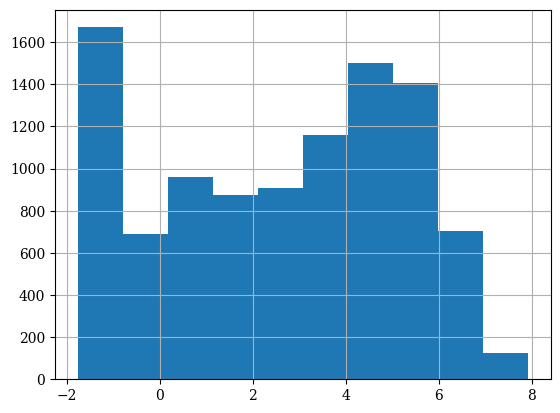

In [9]:
firstDataset['hdelta'].hist()

<Axes: >

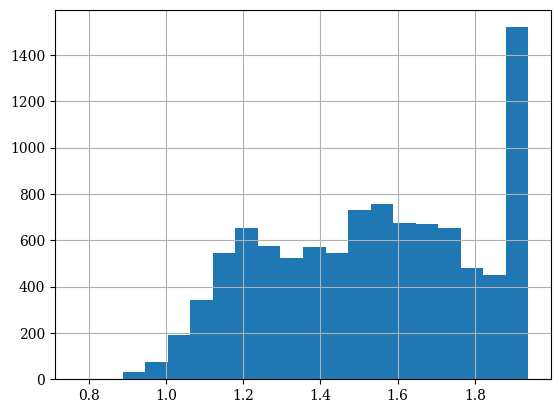

In [10]:
firstDataset['dn4000'].hist(bins=20)

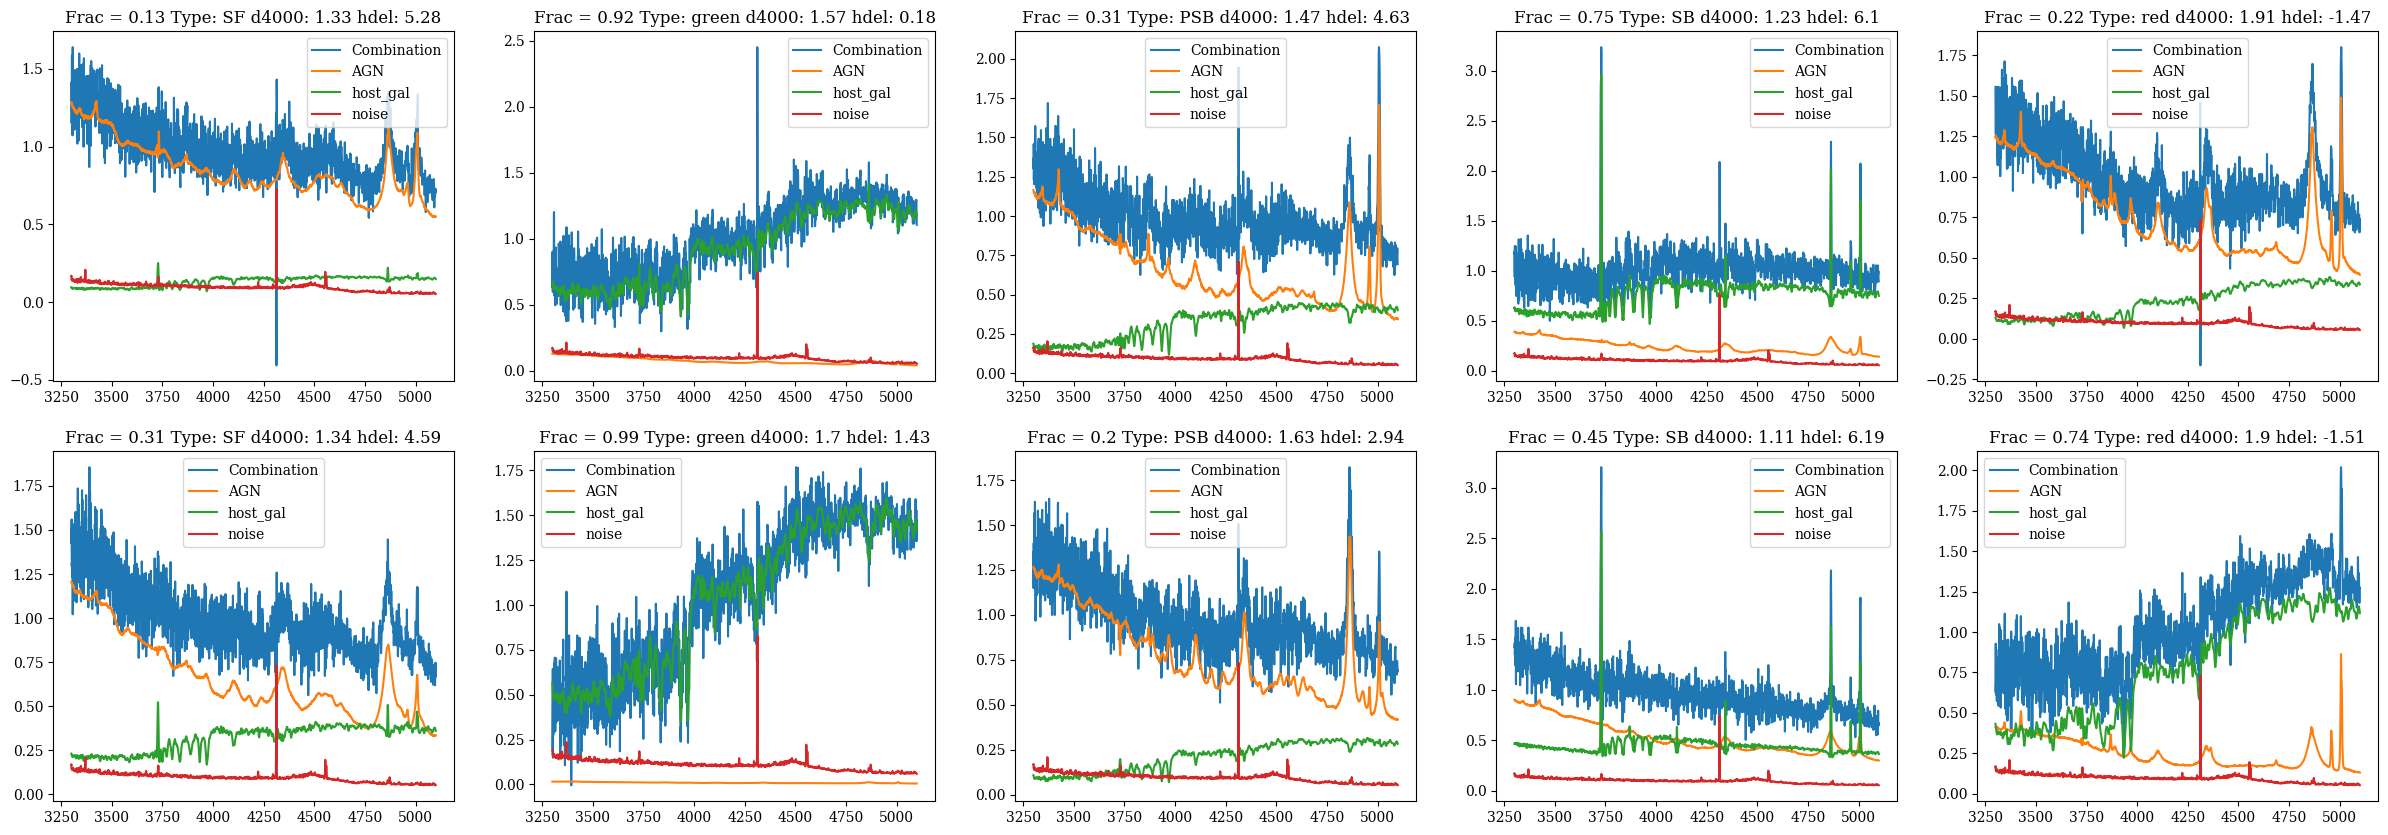

In [11]:
types= ['SF',  'green', 'PSB', 'SB', 'red']
fig, ax = plt.subplots(figsize=(30,10), ncols=5, nrows=2)
uniqueType=[]

i=0
graph=0

while len(uniqueType) < 10: # plot spectra if that gal_type is new
    singleRow=firstDataset.iloc[[i]]
    wl= singleRow['wl'].iloc[0]
    flux= singleRow['flux'].iloc[0]
    true_AGN= singleRow['true_AGN'].iloc[0]
    true_gal= singleRow['true_gal'].iloc[0]
    noise_array=singleRow['error'].iloc[0]
    gal_type=singleRow['gal_type'].iloc[0]
    f_gal= singleRow['f_gal'].iloc[0]
    d4000= singleRow['dn4000'].iloc[0]
    hdel= singleRow['hdelta'].iloc[0]

    i+=1

    typecount=uniqueType.count(gal_type)

    if typecount>=2:
        pass
    else:
        ax[typecount,types.index(gal_type)].plot(wl, flux, label='Combination')
        ax[typecount,types.index(gal_type)].plot(wl, true_AGN, label='AGN')
        ax[typecount,types.index(gal_type)].plot(wl, true_gal, label='host_gal')
        ax[typecount,types.index(gal_type)].plot(wl, noise_array, label='noise')
        ax[typecount,types.index(gal_type)].set_title('Frac = '+str(f_gal)+ ' Type: '+ gal_type + ' d4000: ' +str(round(d4000,2)) + ' hdel: ' + str(round(hdel,2)))
        ax[typecount,types.index(gal_type)].legend()
        if typecount==1:
            graph+=1
        uniqueType.append(gal_type)




### make dataloaders for the simul traning model


In [12]:
# Dataset class for simultaneous traning model
class fullDataSetClass(torch.utils.data.Dataset):
  def __init__(self, flux, fraction, galTypeCode,dn4000,hdelta):
    self.data=flux
    self.f_gal=fraction
    self.galTypeCode=galTypeCode
    self.dn4=dn4000
    self.hdelta=hdelta
    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorF_gal=torch.Tensor(self.f_gal)
    self.tensorGalTypeCode=torch.Tensor(self.galTypeCode)
    self.tensordn4=torch.Tensor(self.dn4)
    self.tensorhdel=torch.Tensor(self.hdelta)


  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_f_gal = self.tensorF_gal[index]
    gal_typeCode = self.tensorGalTypeCode[index]
    dn4_indexed = self.tensordn4[index]
    hdelta_indexed = self.tensorhdel[index]

    return data_point, data_f_gal, gal_typeCode, dn4_indexed,hdelta_indexed

  def  __len__(self):
    return self.size

#create dataset
fullDataset_simul_traning=fullDataSetClass(firstDataset['flux'], firstDataset['f_gal'], firstDataset['gal_type_code'],firstDataset['dn4000'],firstDataset['hdelta'])

In [13]:
#split data set into train, validation, test (8800,200,1000)
trainDataset, testDataset = torch.utils.data.random_split(fullDataset_simul_traning, [9000,1000])
trainDataset, validDataset = torch.utils.data.random_split(trainDataset, [8800,200])

In [14]:
import torch.utils.data as data
# Split data into batches. Also splits data from label, useful when traning the classifier but model is already trained and being loaded in

TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100
train_data_loader = data.DataLoader(trainDataset, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader = data.DataLoader(validDataset, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader = data.DataLoader(testDataset, batch_size=500, shuffle=False)

In [15]:
for batch_flux, batch_f_gal,batch_galType_code, batch_dn4, batch_hdel in train_data_loader:
    print(batch_flux, batch_f_gal,batch_galType_code, batch_dn4, batch_hdel)
    break

tensor([[0.9686, 0.4948, 0.9471,  ..., 1.2115, 1.1104, 1.1828],
        [1.9363, 1.8064, 1.8095,  ..., 0.4449, 0.3347, 0.5380],
        [1.4573, 1.4715, 1.7817,  ..., 0.5981, 0.5515, 0.5707],
        ...,
        [1.3208, 1.3780, 1.3459,  ..., 0.8968, 0.8725, 0.9067],
        [1.2045, 1.1437, 1.3998,  ..., 0.6689, 0.7606, 0.6783],
        [1.1964, 1.0763, 1.0374,  ..., 0.8915, 1.0118, 0.9889]]) tensor([0.8100, 0.0200, 0.4100, 0.9600, 0.6300, 0.5400, 0.6200, 0.3800, 0.1100,
        0.5700, 0.7200, 0.8500, 0.5100, 0.5900, 0.7200, 0.1900, 0.6200, 0.2800,
        0.1300, 0.5700, 0.8100, 0.6200, 0.9500, 0.9200, 0.8900, 0.3900, 0.2600,
        0.7800, 0.7100, 0.1400, 0.0200, 0.4900, 0.6200, 0.7400, 0.5400, 0.4800,
        0.4800, 0.4400, 0.0500, 0.4600]) tensor([0., 1., 1., 1., 4., 1., 2., 1., 0., 0., 3., 1., 2., 3., 3., 1., 4., 1.,
        2., 2., 0., 0., 3., 2., 4., 3., 2., 1., 3., 4., 4., 4., 3., 3., 3., 4.,
        1., 3., 4., 4.]) tensor([1.5032, 1.1415, 1.0729, 1.0502, 1.8373, 0.9335, 

### Make datset for the individual training

In [16]:
# Dataset class for individual traning model
class individualDataSetClass(torch.utils.data.Dataset):
  def __init__(self, flux, label, type_hue):
    self.data=flux
    self.label=label
    self.hue=type_hue

    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorLabel=torch.Tensor(self.label)
    self.tensorHue=torch.Tensor(self.hue)

  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_label = self.tensorLabel[index]
    data_hue = self.tensorHue[index]


    return data_point, data_label, data_hue

  def  __len__(self):
    return self.size

#create dataset
f_gal_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['f_gal'], firstDataset['gal_type_code'])
dn4000_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['dn4000'],firstDataset['gal_type_code'])
hdelta_dataset=individualDataSetClass(firstDataset['flux'], firstDataset['hdelta'],firstDataset['gal_type_code'])

In [17]:
trainDataset_f_gal, testDataset_f_gal = torch.utils.data.random_split(f_gal_dataset, [9000,1000])
trainDataset_f_gal, validDataset_f_gal = torch.utils.data.random_split(trainDataset_f_gal, [8800,200])

trainDataset_dn4, testDataset_dn4 = torch.utils.data.random_split(dn4000_dataset, [9000,1000])
trainDataset_dn4, validDataset_dn4 = torch.utils.data.random_split(trainDataset_dn4, [8800,200])

trainDataset_hdel, testDataset_hdel = torch.utils.data.random_split(hdelta_dataset, [9000,1000])
trainDataset_hdel, validDataset_hdel = torch.utils.data.random_split(trainDataset_hdel, [8800,200])

In [18]:
TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100

train_data_loader_fgal = data.DataLoader(trainDataset_f_gal, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_fgal = data.DataLoader(validDataset_f_gal, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_fgal = data.DataLoader(testDataset_f_gal, batch_size=500, shuffle=False)

train_data_loader_dn4 = data.DataLoader(trainDataset_dn4, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_dn4 = data.DataLoader(validDataset_dn4, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_dn4= data.DataLoader(testDataset_dn4, batch_size=500, shuffle=False)

train_data_loader_hdelta = data.DataLoader(trainDataset_hdel, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_hdelta = data.DataLoader(validDataset_hdel, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_hdelta = data.DataLoader(testDataset_hdel, batch_size=500, shuffle=False)


## ResNet50 Model

### Class

In [19]:
class singleBlock(nn.Module):
    def __init__(self, input_ch, output_ch, kernel, stride):
        super().__init__()

        pad=int((kernel-1)/2)
        self.conv=nn.Conv1d(input_ch, output_ch, kernel, stride, pad)
        self.bn=nn.BatchNorm1d(output_ch)

    def forward(self, x):
        x= self.conv(x)
        x= self.bn(x)
        return x


class residualBlock(nn.Module):
    def __init__(self, input_ch, output_ch, downsample,firstLayerInBlock, stride, bottleNeckRequired):
        super().__init__()

        if firstLayerInBlock:
            downSampleFactor=2
            self.input_ch=int(input_ch/2)
        else:
            downSampleFactor=4
            self.input_ch=input_ch


        self.output_ch=output_ch
        if bottleNeckRequired:
            self.bottleNeckChannelSize=int(self.input_ch/downSampleFactor)
        else:
            self.bottleNeckChannelSize=self.input_ch

        self.conv1=singleBlock(self.input_ch, self.bottleNeckChannelSize, 1, 1)
        self.conv2=singleBlock(self.bottleNeckChannelSize,self.bottleNeckChannelSize,3,stride)
        self.conv3=singleBlock(self.bottleNeckChannelSize, self.output_ch,1,1)
        self.act= nn.ReLU()

        self.downsample=downsample
        if self.input_ch != self.output_ch:
            self.downsample=True
        if self.downsample:
            self.downsampleConv=singleBlock(self.input_ch, self.output_ch, 1,stride)

    def forward(self, x):

        f=self.act(self.conv1(x))
        f=self.act(self.conv2(f))
        f=self.conv3(f)

        if self.downsample:
            x=self.downsampleConv(x)

        h=f+x
        return self.act(h)



class fullResNetModel50(nn.Module):
    def __init__(self, dataChannels, blockList, channelList, finalOutputNo, bottleNeckRequired, stride, chainNumber, **kwargs):
        super().__init__()

        self.blockList=blockList
        self.channelList=channelList
        self.classes=finalOutputNo
        self.stride=stride
        self.chainNumber=chainNumber

        self.firstConv=nn.Conv1d(dataChannels, self.channelList[0], 3,2,3)
        self.BN=nn.BatchNorm1d(self.channelList[0])
        self.act=nn.ReLU()
        self.maxPool=nn.MaxPool1d(3,2,1)

        if self.channelList[0] != self.channelList[1]:
            # takes output from input layer and increase number of channels to size needed to make sure it can add with the first block of middle layers
            self.middleLayerFirstPartUpsample=nn.Conv1d(self.channelList[0], self.channelList[1], 1,1,0)

        self.bottleNeckRequired=bottleNeckRequired # if high number of filters, downsample is needed at the start of layers


        self._createNetwork()
        self._initWeights()


    def _createNetwork(self):
        self.inputLayer=nn.Sequential(
            self.firstConv,
            self.BN,
            self.act,
            self.maxPool
        )



        self.middleLayersPart1=nn.Sequential(
            singleBlock(self.channelList[0], self.channelList[0], 1, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0],self.channelList[0], 3, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0], self.channelList[1], 1, 1),
        )

        self.blockList[1]=self.blockList[1]-1

        self.middleLayersPart2=nn.Sequential()

        for layer in range(1,len(self.blockList)):
            for i in range(self.blockList[layer]):
                #print('layer', layer, 'block', i)

                firstLayerInBlock = True if (i==0 and layer !=1 and self.channelList[layer] != self.channelList[layer-1] ) else False
                stride=self.stride[layer]
                downsample=True if stride == 2 else False # required when size of input and output dont match, which is when stride isnt 1 or inbetween different residual block, the second case is checked in the class

                self.middleLayersPart2.add_module(str(layer)+' '+str(i),
                                                  residualBlock(self.channelList[layer],
                                                                self.channelList[layer],
                                                                downsample,
                                                                firstLayerInBlock,
                                                                stride,
                                                                self.bottleNeckRequired))

                self.outputLayerAvgPool=nn.AdaptiveAvgPool1d(1)
                self.outputflattenLayer=nn.Flatten()
                self.outputFC=nn.Linear(self.channelList[-1]+self.chainNumber, self.classes)




    def _initWeights(self):
        for m in self.modules():
            if (isinstance(m,nn.Conv1d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # test different intialisations, different modes
            elif (isinstance(m, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, previousPredictions=None):
        x=self.inputLayer(x)
        identity=x
        x=self.middleLayersPart1(x) # first block of first layer in middle part

        if self.channelList[0] != self.channelList[1]:
            identity=self.middleLayerFirstPartUpsample(identity)
        x=identity+x
        x=self.act(x)

        x=self.middleLayersPart2(x)
        x=self.outputLayerAvgPool(x) # 1 value per channel
        x=self.outputflattenLayer(x) # flatten to 1 dim

        if previousPredictions != None:
            x=torch.cat((x,previousPredictions), dim=1) # concat the predictions from earlier models

        x=self.outputFC(x)
        return x


## Individual CNNs

In [20]:
def trainModelResNet(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,verbose):

    #train on traning set epochs times

    train_loss_curve=[]
    valid_loss_curve=[]

    classdiffVSepoch=np.array([[],[],[],[],[],[]])
    classdiffVSepoch_valid=np.array([[],[],[],[],[],[]])
    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        allpredictionDiffs=np.array([[],[]])
        model.train()
        for batch_data, batch_label, batch_hue in traindataLoader:
            batch_data=batch_data.unsqueeze(1)
            batch_data=batch_data.to(device) # brings data to cpu or gpu
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            predictionDiff= abs(prediction - batch_label)

            allpredictionDiffs=[np.append(allpredictionDiffs[0], predictionDiff.cpu().detach().numpy()),allpredictionDiffs[1]]
            allpredictionDiffs=[allpredictionDiffs[0],np.append(allpredictionDiffs[1], batch_hue.cpu().numpy())]

            epoch_train_loss += loss.item() # per batch

        class0idx=np.where(allpredictionDiffs[1] == 0)[0]
        class1idx=np.where(allpredictionDiffs[1] == 1)[0]
        class2idx=np.where(allpredictionDiffs[1] == 2)[0]
        class3idx=np.where(allpredictionDiffs[1] == 3)[0]
        class4idx=np.where(allpredictionDiffs[1] == 4)[0]

        classdiffVSepoch=[np.append(classdiffVSepoch[0],np.sum(allpredictionDiffs[0][class0idx])/len(class0idx)),classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],np.append(classdiffVSepoch[1],np.sum(allpredictionDiffs[0][class1idx])/len(class1idx)),classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],np.append(classdiffVSepoch[2],np.sum(allpredictionDiffs[0][class2idx])/len(class2idx)),classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],np.append(classdiffVSepoch[3],np.sum(allpredictionDiffs[0][class3idx])/len(class3idx)),classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],np.append(classdiffVSepoch[4],np.sum(allpredictionDiffs[0][class4idx])/len(class4idx)),classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],np.append(classdiffVSepoch[5],np.sum(allpredictionDiffs[0])/len(allpredictionDiffs[0]))]



        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss, classdiffVSepoch_valid=validate_model(model, validdataLoader, lossCalculator, classdiffVSepoch_valid) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])


        train_loss_curve.append(epoch_train_loss)
        valid_loss_curve.append(epoch_valid_loss)

    return train_loss_curve, valid_loss_curve, classdiffVSepoch ,classdiffVSepoch_valid


def validate_model(model, validdataLoader, lossCalculator,classdiffVSepoch):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        allpredictionDiffs=np.array([[],[]])
        for batch_data, batch_label, batch_hue in validdataLoader:
            batch_data=batch_data.unsqueeze(1)
            batch_data=batch_data.to(device)
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()

            predictionDiff= abs(prediction - batch_label)
            allpredictionDiffs=[np.append(allpredictionDiffs[0], predictionDiff.cpu().detach().numpy()),allpredictionDiffs[1]]
            allpredictionDiffs=[allpredictionDiffs[0],np.append(allpredictionDiffs[1], batch_hue.cpu().numpy())]

            lossValue+=lossCalculator(prediction, batch_label).item()

        class0idx=np.where(allpredictionDiffs[1] == 0)[0]
        class1idx=np.where(allpredictionDiffs[1] == 1)[0]
        class2idx=np.where(allpredictionDiffs[1] == 2)[0]
        class3idx=np.where(allpredictionDiffs[1] == 3)[0]
        class4idx=np.where(allpredictionDiffs[1] == 4)[0]



        classdiffVSepoch=[np.append(classdiffVSepoch[0],np.sum(allpredictionDiffs[0][class0idx])/len(class0idx)),classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],np.append(classdiffVSepoch[1],np.sum(allpredictionDiffs[0][class1idx])/len(class1idx)),classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],np.append(classdiffVSepoch[2],np.sum(allpredictionDiffs[0][class2idx])/len(class2idx)),classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],np.append(classdiffVSepoch[3],np.sum(allpredictionDiffs[0][class3idx])/len(class3idx)),classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],np.append(classdiffVSepoch[4],np.sum(allpredictionDiffs[0][class4idx])/len(class4idx)),classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],np.append(classdiffVSepoch[5],np.sum(allpredictionDiffs[0])/len(allpredictionDiffs[0]))]


        lossValue /= len(validdataLoader)
    return lossValue, classdiffVSepoch

In [21]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_indv=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)


In [22]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_dn4_indv=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

In [23]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_hdelta_indv=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)

In [24]:
optimiser= torch.optim.SGD(model_fgal_indv.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_fgal_indv.to(device)
loss= nn.MSELoss()
M1_fgal_trainLossCurve,M1_fgal_validLossCurve, M1_fgal_MAETrainLossCurve, M1_fgal_MAEValidLossCurve=trainModelResNet(model_fgal_indv, train_data_loader_fgal, valid_data_loader_fgal, optimiser,
                                                     loss, 100, lrScheduler,verbose=True)


optimiser= torch.optim.SGD(model_dn4_indv.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')
model_dn4_indv.to(device)
loss= nn.MSELoss()
M1_dn4_trainLossCurve,M1_dn4_validLossCurve, M1_dn4_MAETrainLossCurve, M1_dn4_MAEValidLossCurve=trainModelResNet(model_dn4_indv, train_data_loader_dn4, valid_data_loader_dn4, optimiser,
                                                                                                                 loss, 100, lrScheduler,verbose=True)


optimiser= torch.optim.SGD(model_hdelta_indv.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')
model_hdelta_indv.to(device)
loss= nn.MSELoss()
M1_hdelta_trainLossCurve,M1_hdelta_validLossCurve, M1_hdelta_MAETrainLossCurve, M1_hdelta_MAEValidLossCurve=trainModelResNet(model_hdelta_indv, train_data_loader_hdelta, valid_data_loader_hdelta, optimiser,
                                                                                                                             loss, 100, lrScheduler,verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.06092870668931441 Valid loss: 0.02780943363904953 lr 0.001
Epoch No: 11 Train loss:  0.010350538136183538 Valid loss: 0.008704273030161858 lr 0.001
Epoch No: 21 Train loss:  0.008580404772973534 Valid loss: 0.0079364946577698 lr 0.001
Epoch No: 31 Train loss:  0.007694870184852995 Valid loss: 0.0074622295796871185 lr 0.001
Epoch No: 41 Train loss:  0.007370966870803386 Valid loss: 0.006479035830125213 lr 0.001
Epoch No: 51 Train loss:  0.006749845736406066 Valid loss: 0.007057153386995196 lr 0.0001
Epoch No: 61 Train loss:  0.006692815941377458 Valid loss: 0.006303524365648627 lr 0.0001
Epoch No: 71 Train loss:  0.0067732456828128885 Valid loss: 0.007133417297154665 lr 0.0001
Epoch No: 81 Train loss:  0.006435669740577313 Valid loss: 0.00703609618358314 lr 1e-05
Epoch No: 91 Train loss:  0.0067129230042072855 Valid loss: 0.007193863391876221 lr 1.0000000000000002e-06


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.1358876971866597 Valid loss: 0.05581955425441265 lr 0.001
Epoch No: 11 Train loss:  0.029700977757403796 Valid loss: 0.03133464977145195 lr 0.001
Epoch No: 21 Train loss:  0.02650221013887362 Valid loss: 0.031085489317774773 lr 0.001
Epoch No: 31 Train loss:  0.024000413152812556 Valid loss: 0.03012049663811922 lr 0.001
Epoch No: 41 Train loss:  0.023304580393331973 Valid loss: 0.029608980752527714 lr 0.0001
Epoch No: 51 Train loss:  0.022980942721055313 Valid loss: 0.025959567166864872 lr 0.0001
Epoch No: 61 Train loss:  0.02272241864438084 Valid loss: 0.026583283208310604 lr 1e-05
Epoch No: 71 Train loss:  0.022646481861275707 Valid loss: 0.025272886268794537 lr 1.0000000000000002e-06
Epoch No: 81 Train loss:  0.022903914313594047 Valid loss: 0.025014464743435383 lr 1.0000000000000002e-06
Epoch No: 91 Train loss:  0.022422744393010032 Valid loss: 0.02623170055449009 lr 1.0000000000000002e-07


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  4.665406879511747 Valid loss: 8.07005763053894 lr 0.001
Epoch No: 11 Train loss:  1.7366125093265012 Valid loss: 1.8406399488449097 lr 0.001
Epoch No: 21 Train loss:  1.215163193643093 Valid loss: 2.430163025856018 lr 0.001
Epoch No: 31 Train loss:  0.5182203632864085 Valid loss: 2.37919819355011 lr 0.0001
Epoch No: 41 Train loss:  0.437223353643309 Valid loss: 2.2112093567848206 lr 1e-05
Epoch No: 51 Train loss:  0.4162079054523598 Valid loss: 2.0845221281051636 lr 1.0000000000000002e-06
Epoch No: 61 Train loss:  0.42953568175435064 Valid loss: 2.1885015964508057 lr 1.0000000000000002e-07
Epoch No: 71 Train loss:  0.4199722864749757 Valid loss: 2.19344961643219 lr 1.0000000000000004e-08
Epoch No: 81 Train loss:  0.4358806781132113 Valid loss: 2.169836461544037 lr 1.0000000000000004e-08
Epoch No: 91 Train loss:  0.399805669283325 Valid loss: 2.160416841506958 lr 1.0000000000000004e-08


#### loss curves

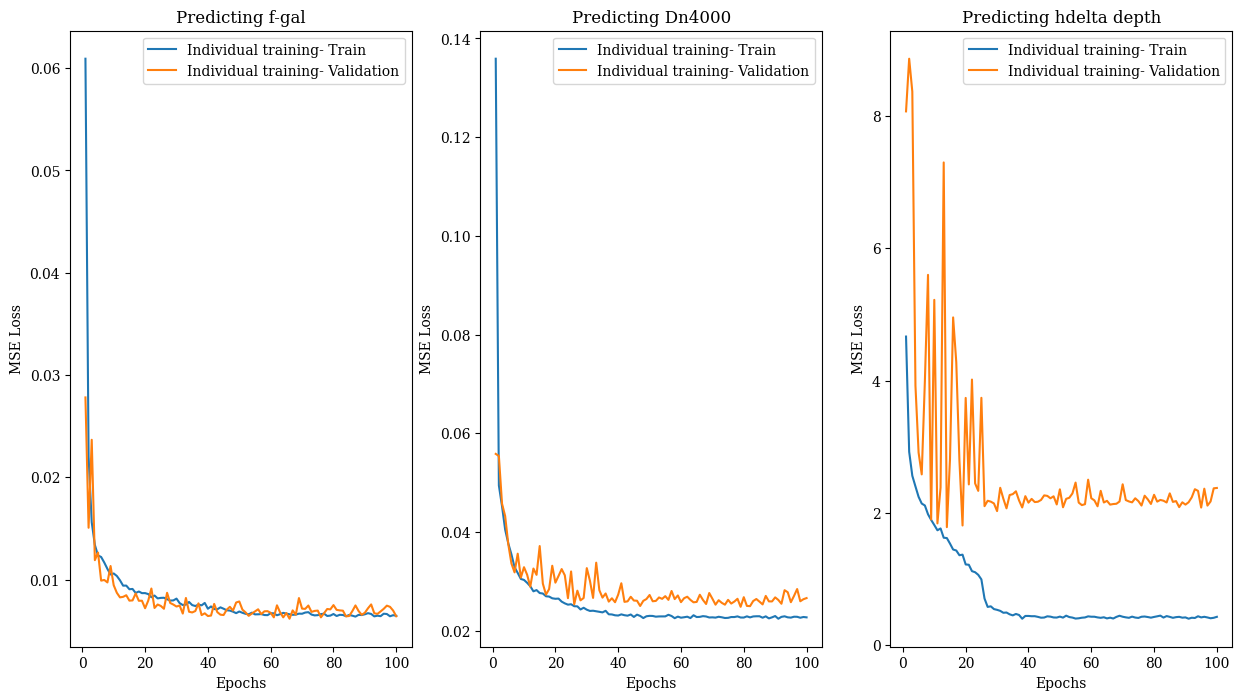

In [25]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M1_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M1_fgal_trainLossCurve, label='Individual training- Train')
ax[1].plot(epoch_array,M1_dn4_trainLossCurve, label='Individual training- Train')
ax[2].plot(epoch_array,M1_hdelta_trainLossCurve, label='Individual training- Train')

ax[0].plot(epoch_array,M1_fgal_validLossCurve, label='Individual training- Validation')
ax[1].plot(epoch_array,M1_dn4_validLossCurve, label='Individual training- Validation')
ax[2].plot(epoch_array,M1_hdelta_validLossCurve, label='Individual training- Validation')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()

In [31]:
len(M1_fgal_MAETrainLossCurve[0])

100

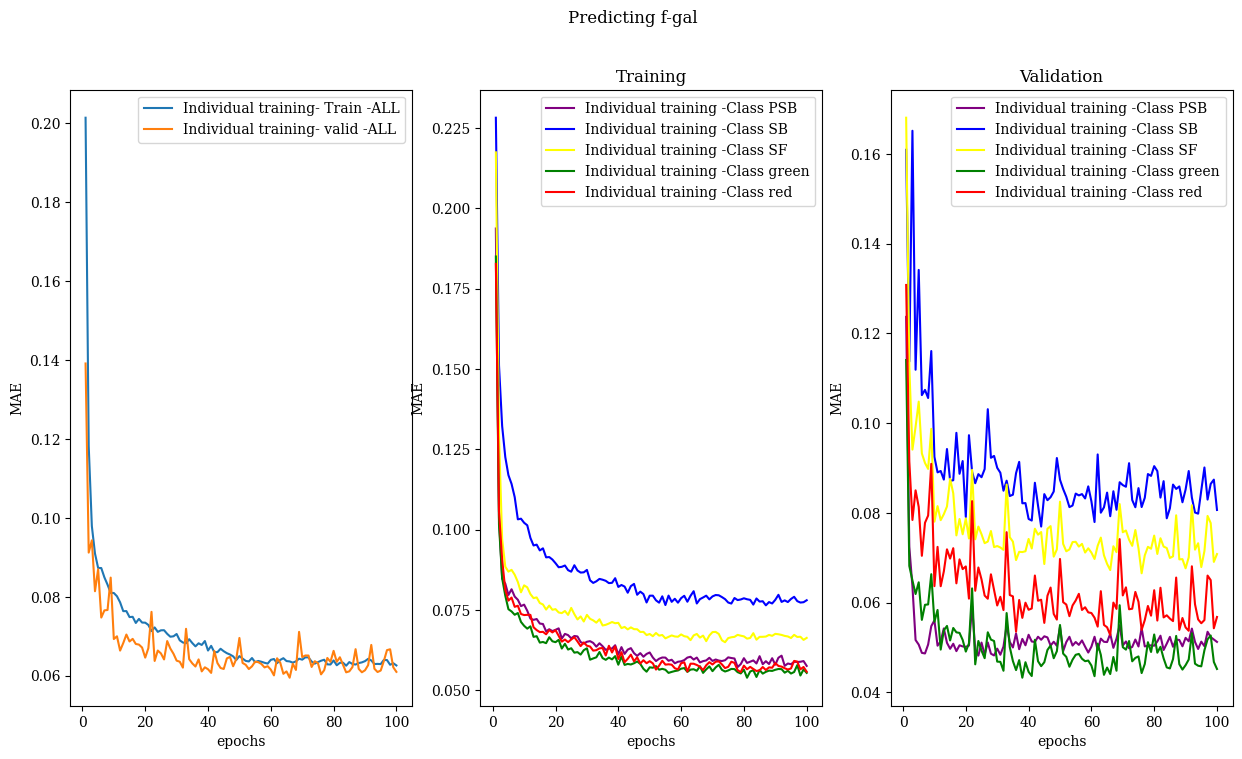

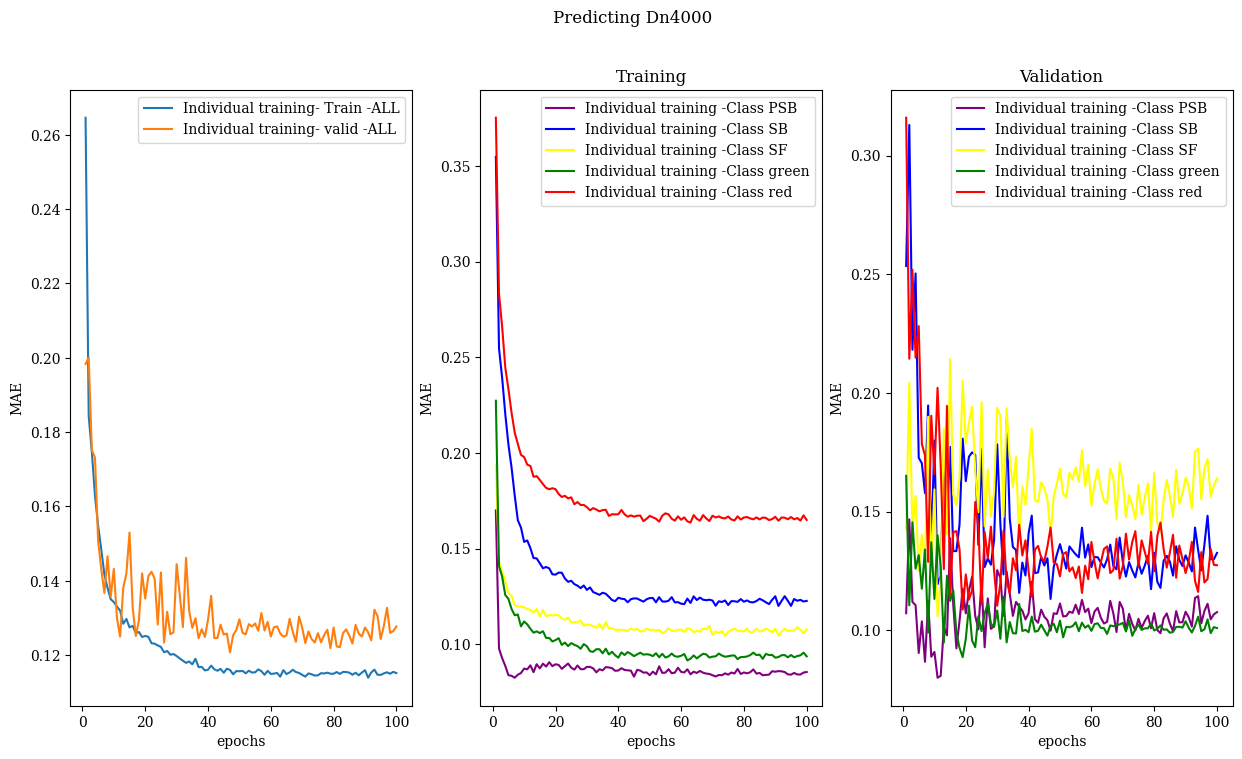

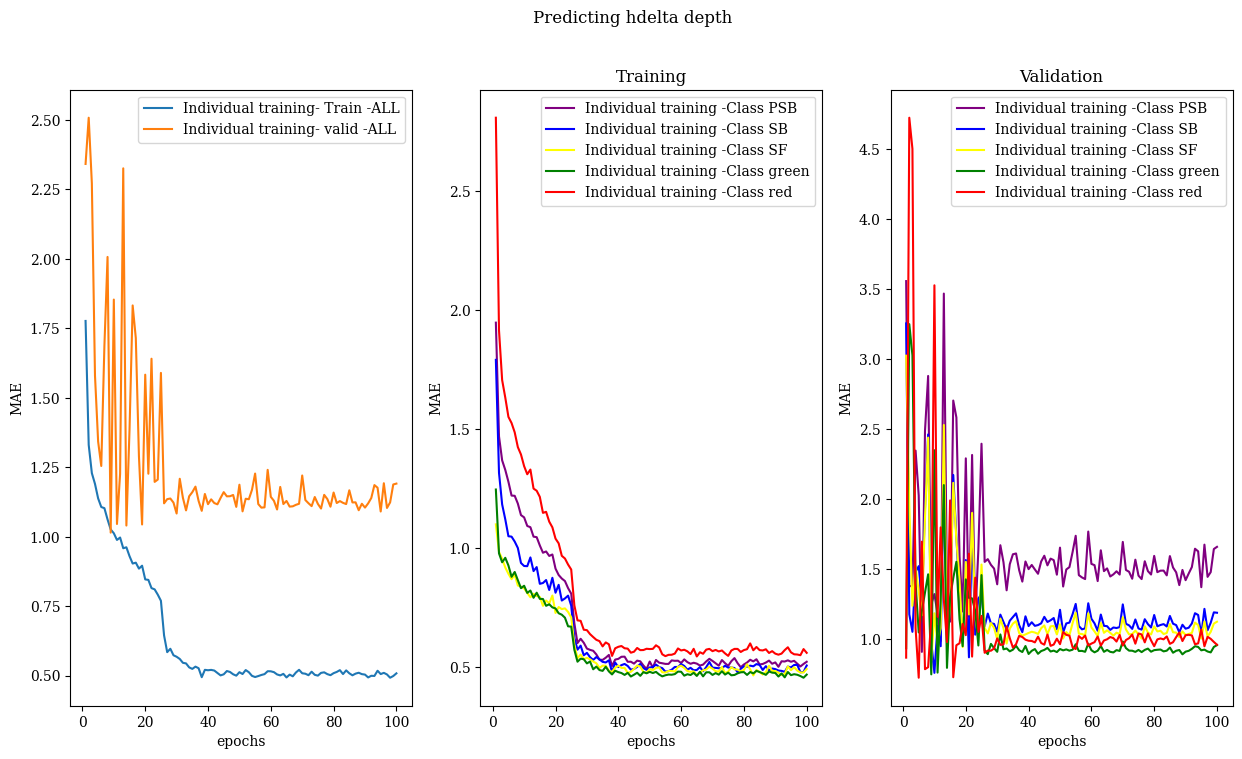

In [36]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)

epoch_array=np.arange(1,len(M1_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M1_fgal_MAETrainLossCurve[5], label='Individual training- Train -ALL')
ax[0].plot(epoch_array,M1_fgal_MAEValidLossCurve[5], label='Individual training- valid -ALL')

ax[1].plot(epoch_array,M1_fgal_MAETrainLossCurve[0], label='Individual training -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M1_fgal_MAETrainLossCurve[1], label='Individual training -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M1_fgal_MAETrainLossCurve[2], label='Individual training -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M1_fgal_MAETrainLossCurve[3], label='Individual training -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[1].plot(epoch_array,M1_fgal_MAETrainLossCurve[4], label='Individual training -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M1_fgal_MAEValidLossCurve[0], label='Individual training -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M1_fgal_MAEValidLossCurve[1], label='Individual training -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M1_fgal_MAEValidLossCurve[2], label='Individual training -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M1_fgal_MAEValidLossCurve[3], label='Individual training -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[2].plot(epoch_array,M1_fgal_MAEValidLossCurve[4], label='Individual training -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M1_dn4_MAETrainLossCurve[5], label='Individual training- Train -ALL')
ax2[0].plot(epoch_array,M1_dn4_MAEValidLossCurve[5], label='Individual training- valid -ALL')

ax2[1].plot(epoch_array,M1_dn4_MAETrainLossCurve[0], label='Individual training -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M1_dn4_MAETrainLossCurve[1], label='Individual training -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M1_dn4_MAETrainLossCurve[2], label='Individual training -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M1_dn4_MAETrainLossCurve[3], label='Individual training -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[1].plot(epoch_array,M1_dn4_MAETrainLossCurve[4], label='Individual training -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M1_dn4_MAEValidLossCurve[0], label='Individual training -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M1_dn4_MAEValidLossCurve[1], label='Individual training -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M1_dn4_MAEValidLossCurve[2], label='Individual training -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M1_dn4_MAEValidLossCurve[3], label='Individual training -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[2].plot(epoch_array,M1_dn4_MAEValidLossCurve[4], label='Individual training -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M1_hdelta_MAETrainLossCurve[5], label='Individual training- Train -ALL')
ax3[0].plot(epoch_array,M1_hdelta_MAEValidLossCurve[5], label='Individual training- valid -ALL')

ax3[1].plot(epoch_array,M1_hdelta_MAETrainLossCurve[0], label='Individual training -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M1_hdelta_MAETrainLossCurve[1], label='Individual training -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M1_hdelta_MAETrainLossCurve[2], label='Individual training -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M1_hdelta_MAETrainLossCurve[3], label='Individual training -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[1].plot(epoch_array,M1_hdelta_MAETrainLossCurve[4], label='Individual training -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M1_hdelta_MAEValidLossCurve[0], label='Individual training -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M1_hdelta_MAEValidLossCurve[1], label='Individual training -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M1_hdelta_MAEValidLossCurve[2], label='Individual training -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M1_hdelta_MAEValidLossCurve[3], label='Individual training -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[2].plot(epoch_array,M1_hdelta_MAEValidLossCurve[4], label='Individual training -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()

## Individually trained but connected CNNs

- connect at start
- connect at fully connected section

### connected at the start

In [37]:
def trainModelResNet_sequential(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,verbose):

    #train on traning set epochs times
    train_loss_curve=[]
    valid_loss_curve=[]
    classdiffVSepoch=np.array([[],[],[],[],[],[]])
    classdiffVSepoch_valid=np.array([[],[],[],[],[],[]])
    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        model.train()
        allpredictionDiffs=np.array([[],[]])
        for batch_data, batch_label, _, _, batch_hue in traindataLoader:

            batch_data=batch_data.to(device) # brings data to cpu or gpu
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            predictionDiff= abs(prediction - batch_label)

            allpredictionDiffs=[np.append(allpredictionDiffs[0], predictionDiff.cpu().detach().numpy()),allpredictionDiffs[1]]
            allpredictionDiffs=[allpredictionDiffs[0],np.append(allpredictionDiffs[1], batch_hue.cpu().numpy())]

            epoch_train_loss += loss.item() # per batch

        class0idx=np.where(allpredictionDiffs[1] == 0)[0]
        class1idx=np.where(allpredictionDiffs[1] == 1)[0]
        class2idx=np.where(allpredictionDiffs[1] == 2)[0]
        class3idx=np.where(allpredictionDiffs[1] == 3)[0]
        class4idx=np.where(allpredictionDiffs[1] == 4)[0]

        classdiffVSepoch=[np.append(classdiffVSepoch[0],np.sum(allpredictionDiffs[0][class0idx])/len(class0idx)),classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],np.append(classdiffVSepoch[1],np.sum(allpredictionDiffs[0][class1idx])/len(class1idx)),classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],np.append(classdiffVSepoch[2],np.sum(allpredictionDiffs[0][class2idx])/len(class2idx)),classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],np.append(classdiffVSepoch[3],np.sum(allpredictionDiffs[0][class3idx])/len(class3idx)),classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],np.append(classdiffVSepoch[4],np.sum(allpredictionDiffs[0][class4idx])/len(class4idx)),classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],np.append(classdiffVSepoch[5],np.sum(allpredictionDiffs[0])/len(allpredictionDiffs[0]))]


        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss, classdiffVSepoch_valid =validate_model_sequential(model, validdataLoader, lossCalculator, classdiffVSepoch_valid) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])


        train_loss_curve.append(epoch_train_loss)
        valid_loss_curve.append(epoch_valid_loss)

    return train_loss_curve, valid_loss_curve, classdiffVSepoch, classdiffVSepoch_valid



def validate_model_sequential(model, validdataLoader, lossCalculator, classdiffVSepoch):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        allpredictionDiffs=np.array([[],[]])
        for batch_data, batch_label, _ ,_, batch_hue in validdataLoader:
            batch_data=batch_data.to(device)
            batch_label=batch_label.to(device)

            prediction=model(batch_data).squeeze()
            lossValue+=lossCalculator(prediction, batch_label).item()

            predictionDiff= abs(prediction - batch_label)

            allpredictionDiffs=[np.append(allpredictionDiffs[0], predictionDiff.cpu().detach().numpy()),allpredictionDiffs[1]]
            allpredictionDiffs=[allpredictionDiffs[0],np.append(allpredictionDiffs[1], batch_hue.cpu().numpy())]

        class0idx=np.where(allpredictionDiffs[1] == 0)[0]
        class1idx=np.where(allpredictionDiffs[1] == 1)[0]
        class2idx=np.where(allpredictionDiffs[1] == 2)[0]
        class3idx=np.where(allpredictionDiffs[1] == 3)[0]
        class4idx=np.where(allpredictionDiffs[1] == 4)[0]

        classdiffVSepoch=[np.append(classdiffVSepoch[0],np.sum(allpredictionDiffs[0][class0idx])/len(class0idx)),classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],np.append(classdiffVSepoch[1],np.sum(allpredictionDiffs[0][class1idx])/len(class1idx)),classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],np.append(classdiffVSepoch[2],np.sum(allpredictionDiffs[0][class2idx])/len(class2idx)),classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],np.append(classdiffVSepoch[3],np.sum(allpredictionDiffs[0][class3idx])/len(class3idx)),classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],np.append(classdiffVSepoch[4],np.sum(allpredictionDiffs[0][class4idx])/len(class4idx)),classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],np.append(classdiffVSepoch[5],np.sum(allpredictionDiffs[0])/len(allpredictionDiffs[0]))]


        lossValue /= len(validdataLoader)
    return lossValue, classdiffVSepoch

In [38]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class MASTERDATASET(torch.utils.data.Dataset):
  def __init__(self, flux, f_gal, dn4000, hdelta, type_hue):
    self.data=flux
    self.f_gal=f_gal
    self.dn4000=dn4000
    self.hdelta=hdelta
    self.hue=type_hue

    self.generateData()
    self.size=len(self.data)

  def generateData(self):
    self.tensordata=torch.Tensor(self.data)
    self.tensorf_gal=torch.Tensor(self.f_gal)
    self.tensor_dn4000=torch.Tensor(self.dn4000)
    self.tensor_hdelta=torch.Tensor(self.hdelta)
    self.tensor_Hue=torch.Tensor(self.hue)

  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_f_gal = self.tensorf_gal[index]
    data_dn400 =self.tensor_dn4000[index]
    data_hdelta =self.tensor_hdelta[index]
    data_hue = self.tensor_Hue[index]


    return data_point, data_f_gal, data_dn400, data_hdelta, data_hue

  def  __len__(self):
    return self.size

#create dataset
masterData=MASTERDATASET(firstDataset['flux'], firstDataset['f_gal'], firstDataset['dn4000'], firstDataset['hdelta'], firstDataset['gal_type_code'])


In [39]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class modifiedDataset(torch.utils.data.Dataset):
    def __init__(self, masterData, predicted_Data_f_gal, predicted_Data_dn4000, dataName):
        self.master=masterData
        self.predicted_Data_fgal=predicted_Data_f_gal
        self.predicted_Data_dn4000=predicted_Data_dn4000
        self.dataName=dataName

        self.generateData()
        self.size=len(self.master)

    def generateData(self):
        self.tensorPredicted_fgal=torch.Tensor(self.predicted_Data_fgal) if self.predicted_Data_fgal != None else None
        self.tensorPredicted_dn4000=torch.Tensor(self.predicted_Data_dn4000) if self.predicted_Data_dn4000 != None else None



    def __getitem__(self, index):
        if self.dataName=='f-gal':
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.unsqueeze(0)
            return data_flux, data_f_gal,data_dn4000 , data_hdelta, data_gal_type_code

        elif self.dataName=='dn4000':
            data_flux, data_f_gal , data_dn4000, data_hdelta ,data_gal_type_code= self.master[index]

            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_fgal[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)


            modified_batch_flux= torch.concat((data_flux, newChannel), dim=0)

            return modified_batch_flux ,data_dn4000, data_f_gal, data_hdelta,data_gal_type_code

        elif self.dataName=='hdelta':
            data_flux , data_dn4000, data_f_gal,data_hdelta,data_gal_type_code= self.master[index]

            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_dn4000[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.cat((data_flux, newChannel), dim=0) # add dn4000

            return modified_batch_flux, data_hdelta, data_f_gal , data_dn4000 , data_gal_type_code

        #return data_point, data_f_gal, data_dn400, data_hdelta, data_hue

    def  __len__(self):
        return self.size

In [40]:
f_galData=modifiedDataset(masterData, None, None, 'f-gal')

In [41]:
for i,h,j,k,l in f_galData:
    print(i,h,j,k,l)
    print(i.shape)
    break

tensor([[1.5542, 1.3226, 1.2657,  ..., 0.6589, 0.6553, 0.7390]]) tensor(0.2200) tensor(1.9056) tensor(-1.4662) tensor(4.)
torch.Size([1, 1890])


In [42]:
trainDataset_f_gal_V2, testDataset_f_gal_V2 = torch.utils.data.random_split(f_galData, [9000,1000])
trainDataset_f_gal_V2, validDataset_f_gal_V2 = torch.utils.data.random_split(trainDataset_f_gal_V2, [8800,200])

In [43]:
TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100

train_data_loader_fgal_V2 = data.DataLoader(trainDataset_f_gal_V2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_fgal_V2 = data.DataLoader(validDataset_f_gal_V2, batch_size=VALID_BATCH_SIZE, shuffle=False)
test_data_loader_fgal_V2 = data.DataLoader(testDataset_f_gal_V2, batch_size=500, shuffle=False)

In [44]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_Version2=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)


optimiser= torch.optim.SGD(model_fgal_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_fgal_Version2.to(device)
loss= nn.MSELoss()
M2_fgal_trainLossCurve,M2_fgal_validLossCurve, M2_fgal_MAETrainLossCurve, M2_fgal_MAEValidLossCurve=trainModelResNet_sequential(model_fgal_Version2, train_data_loader_fgal_V2, valid_data_loader_fgal_V2, optimiser,
                                                                                                                                    loss, 100, lrScheduler,verbose=True)



  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.057285402004014364 Valid loss: 0.033479129895567894 lr 0.001
Epoch No: 11 Train loss:  0.010333112002858384 Valid loss: 0.0068178491201251745 lr 0.001
Epoch No: 21 Train loss:  0.009010078952732412 Valid loss: 0.007663042517378926 lr 0.001
Epoch No: 31 Train loss:  0.008261809466322037 Valid loss: 0.0055681520607322454 lr 0.001
Epoch No: 41 Train loss:  0.007507234823424369 Valid loss: 0.0055806939490139484 lr 0.001
Epoch No: 51 Train loss:  0.006994268213483421 Valid loss: 0.00506849167868495 lr 0.001
Epoch No: 61 Train loss:  0.006710906568067995 Valid loss: 0.004914237419143319 lr 0.001
Epoch No: 71 Train loss:  0.006283385172189976 Valid loss: 0.005025478545576334 lr 0.001
Epoch No: 81 Train loss:  0.006099023175722158 Valid loss: 0.005017400253564119 lr 0.0001
Epoch No: 91 Train loss:  0.006181381581435827 Valid loss: 0.004858094500377774 lr 1e-05


In [51]:
# Then apply model, take predictions and concat to the traning set

# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_F_gal_predictions = data.DataLoader(trainDataset_f_gal_V2, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_fgal_Version2.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_F_gal_predictions:
        prediction = model_fgal_Version2(batch_data.to(device))
        prediction_train.append(prediction)

    for batch_data,_,_,_,_ in valid_data_loader_fgal_V2:
        prediction = model_fgal_Version2(batch_data.to(device))
        prediction_valid.append(prediction)


prediction_train_fgal=torch.concat(prediction_train, dim=0)
prediction_valid_fgal=torch.concat(prediction_valid, dim=0)

In [52]:
dn4000_dataset_train=modifiedDataset(trainDataset_f_gal_V2, prediction_train_fgal, None, 'dn4000')
dn4000_dataset_valid=modifiedDataset(validDataset_f_gal_V2, prediction_valid_fgal, None, 'dn4000')

train_data_loader_dn4000_V2 = data.DataLoader(dn4000_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_dn4000_V2 = data.DataLoader(dn4000_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [53]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_dn4000_Version2=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


optimiser= torch.optim.SGD(model_dn4000_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_dn4000_Version2.to(device)
loss= nn.MSELoss()
M2_dn4_trainLossCurve,M2_dn4_validLossCurve,M2_dn4_MAETrainLossCurve, M2_dn4_MAEValidLossCurve=trainModelResNet_sequential(model_dn4000_Version2, train_data_loader_dn4000_V2, valid_data_loader_dn4000_V2, optimiser,
                                                                                                                             loss, 100, lrScheduler,verbose=True)



  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.1266635646704923 Valid loss: 0.04642225429415703 lr 0.001
Epoch No: 11 Train loss:  0.02718825074420734 Valid loss: 0.0218349639326334 lr 0.001
Epoch No: 21 Train loss:  0.024755345276472242 Valid loss: 0.022396914660930634 lr 0.001
Epoch No: 31 Train loss:  0.024061713316901163 Valid loss: 0.023298236541450024 lr 0.0001
Epoch No: 41 Train loss:  0.0240053418812088 Valid loss: 0.023114612326025963 lr 1e-05
Epoch No: 51 Train loss:  0.02401399436745454 Valid loss: 0.02424243837594986 lr 1.0000000000000002e-06
Epoch No: 61 Train loss:  0.023843787411566484 Valid loss: 0.023063885048031807 lr 1.0000000000000002e-07
Epoch No: 71 Train loss:  0.024052272267131643 Valid loss: 0.02371144574135542 lr 1.0000000000000004e-08
Epoch No: 81 Train loss:  0.023801078329878773 Valid loss: 0.02282254584133625 lr 1.0000000000000004e-08
Epoch No: 91 Train loss:  0.023932074560699138 Valid loss: 0.0230788616463542 lr 1.0000000000000004e-08


In [54]:
# Then apply model, take predictions and concat to the traning set

# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_dn4000_predictions = data.DataLoader(dn4000_dataset_train, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_dn4000_Version2.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_dn4000_predictions:
        prediction = model_dn4000_Version2(batch_data.to(device))
        prediction_train.append(prediction)


    for batch_data,_,_,_,_ in valid_data_loader_dn4000_V2:
        prediction = model_dn4000_Version2(batch_data.to(device))
        prediction_valid.append(prediction)


prediction_train_dn4000=torch.concat(prediction_train, dim=0)
prediction_valid_dn4000=torch.concat(prediction_valid, dim=0)

In [55]:
hdelta_dataset_train=modifiedDataset(dn4000_dataset_train,  None,prediction_train_dn4000, 'hdelta')
hdelta_dataset_valid=modifiedDataset(dn4000_dataset_valid,  None,prediction_valid_dn4000, 'hdelta')

train_data_loader_hdelta_V2 = data.DataLoader(hdelta_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_hdelta_V2 = data.DataLoader(hdelta_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [56]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_hdelta_Version2=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)


optimiser= torch.optim.SGD(model_hdelta_Version2.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_hdelta_Version2.to(device)
loss= nn.MSELoss()
M2_hdelta_trainLossCurve,M2_hdelta_validLossCurve, M2_hdelta_MAETrainLossCurve, M2_hdelta_MAEValidLossCurve=trainModelResNet_sequential(model_hdelta_Version2, train_data_loader_hdelta_V2, valid_data_loader_hdelta_V2, optimiser,
                                                                                                                                    loss, 100, lrScheduler,verbose=True)



  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  3.1286594434217974 Valid loss: 2.8621906042099 lr 0.001
Epoch No: 11 Train loss:  2.0436308817429976 Valid loss: 2.1318938732147217 lr 0.001
Epoch No: 21 Train loss:  1.6106044436042959 Valid loss: 1.8210877180099487 lr 0.001
Epoch No: 31 Train loss:  1.3380262648517436 Valid loss: 1.9398553371429443 lr 0.001
Epoch No: 41 Train loss:  1.0693362043662504 Valid loss: 1.9272560477256775 lr 0.001
Epoch No: 51 Train loss:  0.5494795860214667 Valid loss: 1.569119930267334 lr 0.0001
Epoch No: 61 Train loss:  0.44813791858879004 Valid loss: 1.5721744298934937 lr 0.0001
Epoch No: 71 Train loss:  0.40815364962274375 Valid loss: 1.6435174942016602 lr 1e-05
Epoch No: 81 Train loss:  0.39939045919613403 Valid loss: 1.6450508832931519 lr 1.0000000000000002e-06
Epoch No: 91 Train loss:  0.4064467412504283 Valid loss: 1.6673307418823242 lr 1.0000000000000002e-07


In [57]:
for i in train_data_loader_hdelta_V2:
    print(i[0])
    print(i[2])
    print(i[3])
    break

tensor([[[1.4682, 1.3397, 1.0877,  ..., 0.7370, 0.7744, 0.6636],
         [0.1848, 0.1848, 0.1848,  ..., 0.1848, 0.1848, 0.1848],
         [1.5015, 1.5015, 1.5015,  ..., 1.5015, 1.5015, 1.5015]],

        [[0.6483, 0.7782, 0.6336,  ..., 1.5196, 1.5659, 1.5223],
         [0.8623, 0.8623, 0.8623,  ..., 0.8623, 0.8623, 0.8623],
         [1.9914, 1.9914, 1.9914,  ..., 1.9914, 1.9914, 1.9914]],

        [[1.4173, 1.2836, 1.6432,  ..., 0.6640, 0.6105, 0.6625],
         [0.1931, 0.1931, 0.1931,  ..., 0.1931, 0.1931, 0.1931],
         [1.5389, 1.5389, 1.5389,  ..., 1.5389, 1.5389, 1.5389]],

        ...,

        [[1.4152, 1.2630, 1.1491,  ..., 0.6961, 0.7439, 0.6982],
         [0.1806, 0.1806, 0.1806,  ..., 0.1806, 0.1806, 0.1806],
         [1.6848, 1.6848, 1.6848,  ..., 1.6848, 1.6848, 1.6848]],

        [[0.8405, 0.9032, 0.6246,  ..., 1.3529, 1.3674, 1.3170],
         [0.8441, 0.8441, 0.8441,  ..., 0.8441, 0.8441, 0.8441],
         [1.7006, 1.7006, 1.7006,  ..., 1.7006, 1.7006, 1.7006]],

 

#### loss curves

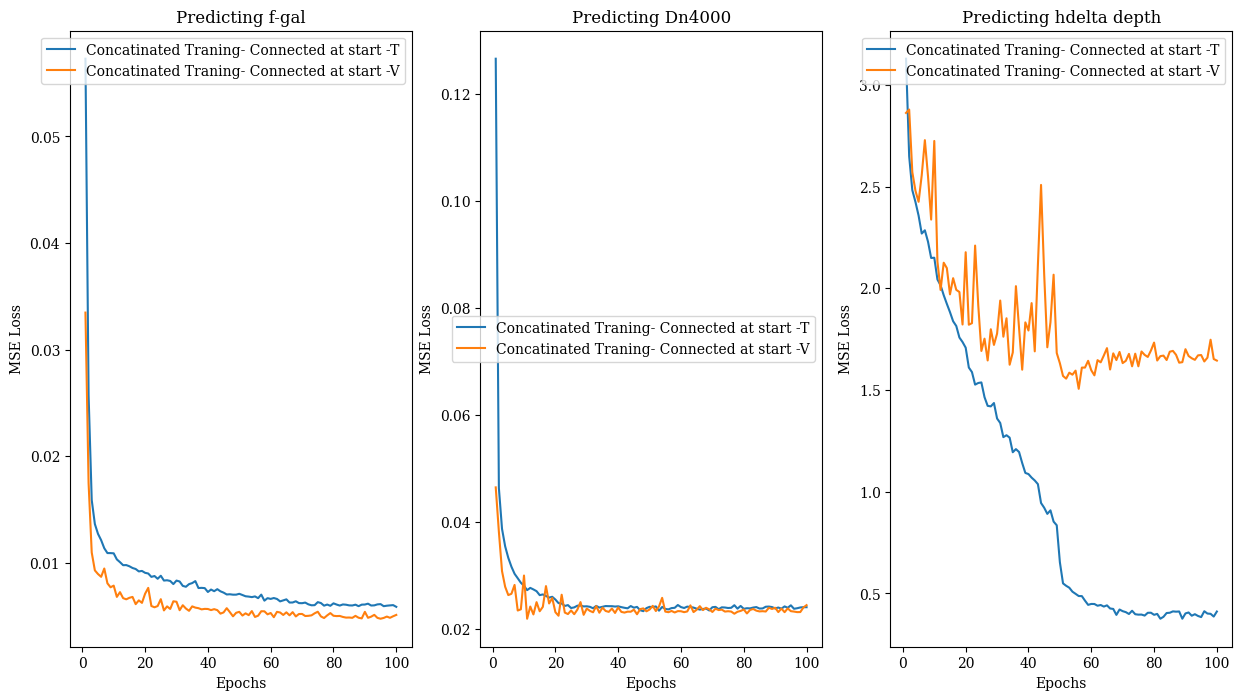

In [58]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M2_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M2_fgal_trainLossCurve, label='Concatinated Traning- Connected at start -T')
ax[1].plot(epoch_array,M2_dn4_trainLossCurve, label='Concatinated Traning- Connected at start -T')
ax[2].plot(epoch_array,M2_hdelta_trainLossCurve, label='Concatinated Traning- Connected at start -T')

ax[0].plot(epoch_array,M2_fgal_validLossCurve, label='Concatinated Traning- Connected at start -V')
ax[1].plot(epoch_array,M2_dn4_validLossCurve, label='Concatinated Traning- Connected at start -V')
ax[2].plot(epoch_array,M2_hdelta_validLossCurve, label='Concatinated Traning- Connected at start -V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()

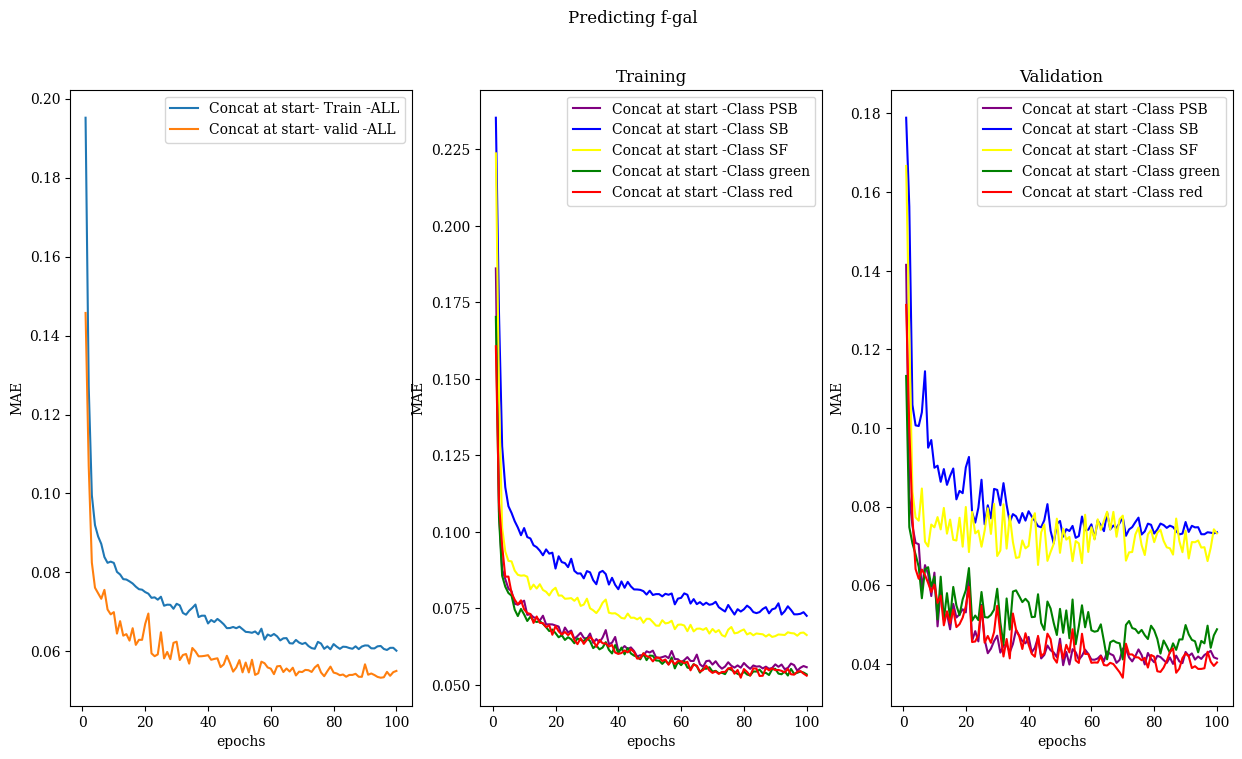

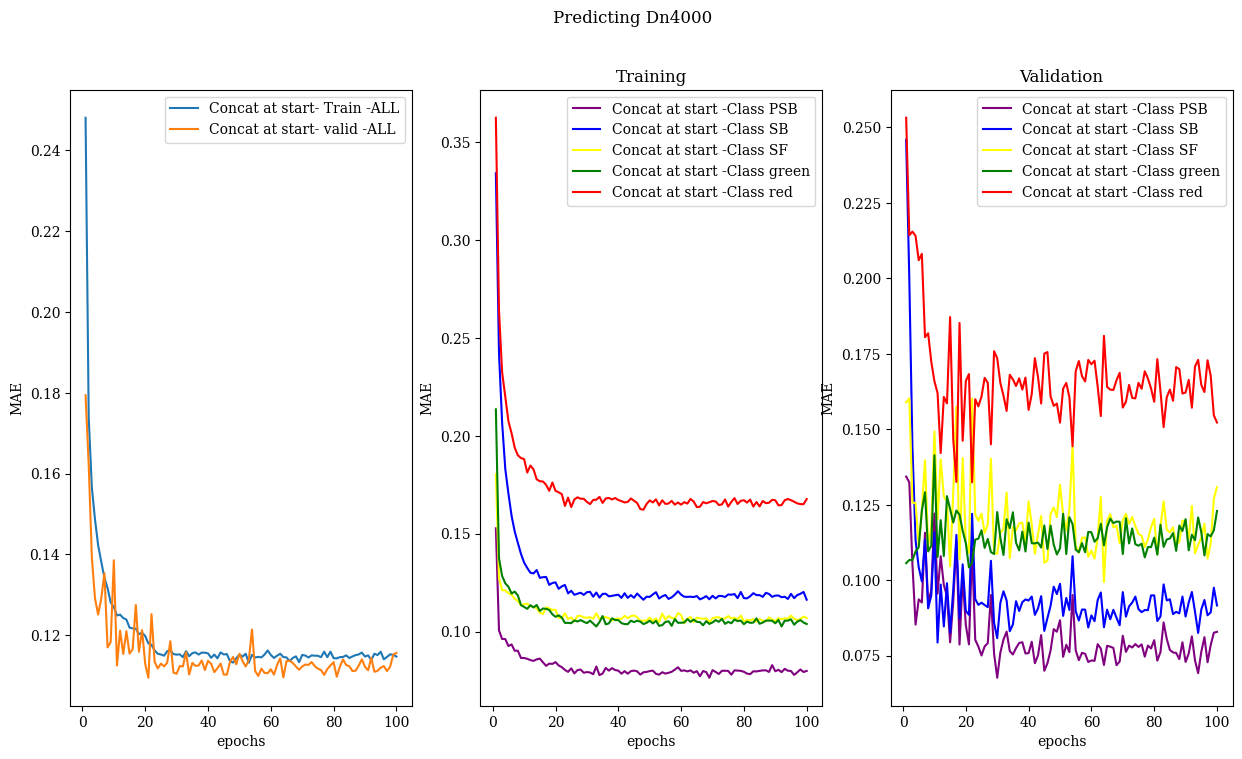

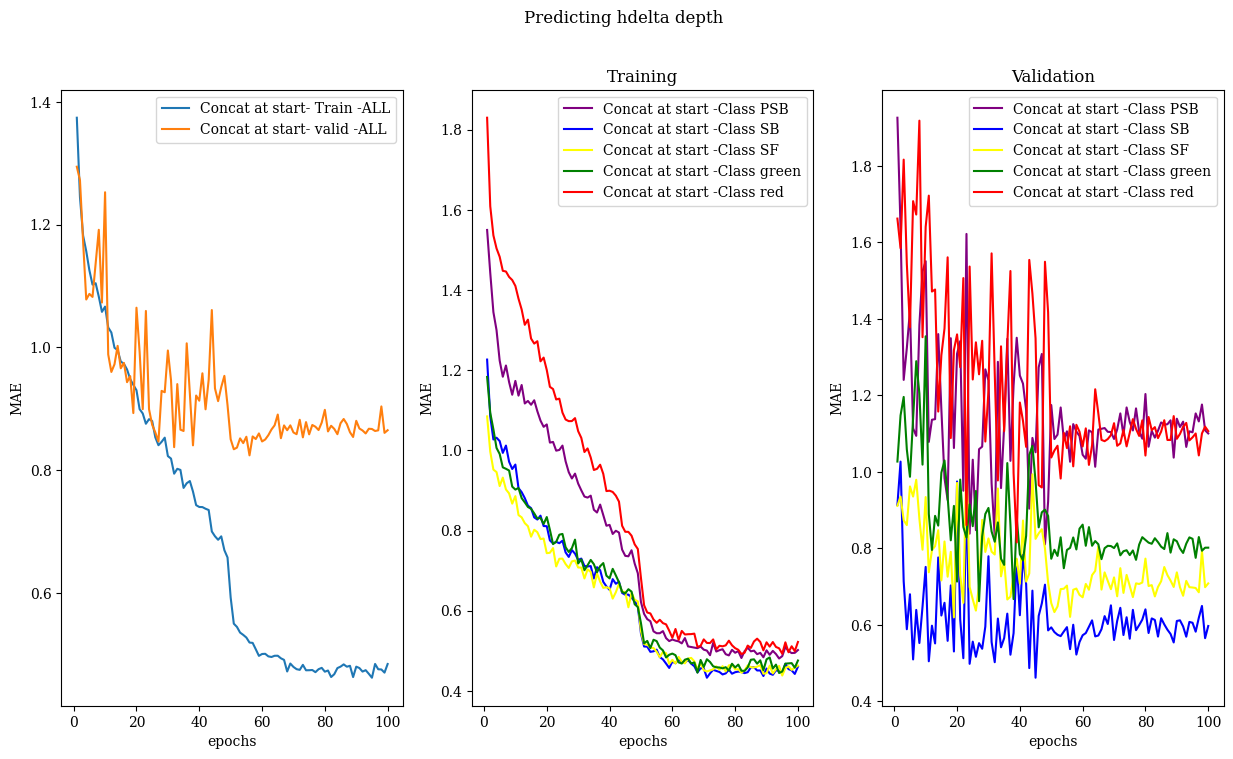

In [59]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)

epoch_array=np.arange(1,len(M2_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M2_fgal_MAETrainLossCurve[5], label='Concat at start- Train -ALL')
ax[0].plot(epoch_array,M2_fgal_MAEValidLossCurve[5], label='Concat at start- valid -ALL')

ax[1].plot(epoch_array,M2_fgal_MAETrainLossCurve[0], label='Concat at start -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M2_fgal_MAETrainLossCurve[1], label='Concat at start -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M2_fgal_MAETrainLossCurve[2], label='Concat at start -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M2_fgal_MAETrainLossCurve[3], label='Concat at start -Class '+str(le.inverse_transform([3])[0]), color='green')
ax[1].plot(epoch_array,M2_fgal_MAETrainLossCurve[4], label='Concat at start -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M2_fgal_MAEValidLossCurve[0], label='Concat at start -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M2_fgal_MAEValidLossCurve[1], label='Concat at start -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M2_fgal_MAEValidLossCurve[2], label='Concat at start -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M2_fgal_MAEValidLossCurve[3], label='Concat at start -Class '+str(le.inverse_transform([3])[0]), color='green')
ax[2].plot(epoch_array,M2_fgal_MAEValidLossCurve[4], label='Concat at start -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M2_dn4_MAETrainLossCurve[5], label='Concat at start- Train -ALL')
ax2[0].plot(epoch_array,M2_dn4_MAEValidLossCurve[5], label='Concat at start- valid -ALL')

ax2[1].plot(epoch_array,M2_dn4_MAETrainLossCurve[0], label='Concat at start -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M2_dn4_MAETrainLossCurve[1], label='Concat at start -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M2_dn4_MAETrainLossCurve[2], label='Concat at start -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M2_dn4_MAETrainLossCurve[3], label='Concat at start -Class '+str(le.inverse_transform([3])[0]), color='green')
ax2[1].plot(epoch_array,M2_dn4_MAETrainLossCurve[4], label='Concat at start -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M2_dn4_MAEValidLossCurve[0], label='Concat at start -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M2_dn4_MAEValidLossCurve[1], label='Concat at start -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M2_dn4_MAEValidLossCurve[2], label='Concat at start -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M2_dn4_MAEValidLossCurve[3], label='Concat at start -Class '+str(le.inverse_transform([3])[0]), color='green')
ax2[2].plot(epoch_array,M2_dn4_MAEValidLossCurve[4], label='Concat at start -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M2_hdelta_MAETrainLossCurve[5], label='Concat at start- Train -ALL')
ax3[0].plot(epoch_array,M2_hdelta_MAEValidLossCurve[5], label='Concat at start- valid -ALL')

ax3[1].plot(epoch_array,M2_hdelta_MAETrainLossCurve[0], label='Concat at start -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M2_hdelta_MAETrainLossCurve[1], label='Concat at start -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M2_hdelta_MAETrainLossCurve[2], label='Concat at start -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M2_hdelta_MAETrainLossCurve[3], label='Concat at start -Class '+str(le.inverse_transform([3])[0]), color='green')
ax3[1].plot(epoch_array,M2_hdelta_MAETrainLossCurve[4], label='Concat at start -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M2_hdelta_MAEValidLossCurve[0], label='Concat at start -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M2_hdelta_MAEValidLossCurve[1], label='Concat at start -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M2_hdelta_MAEValidLossCurve[2], label='Concat at start -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M2_hdelta_MAEValidLossCurve[3], label='Concat at start -Class '+str(le.inverse_transform([3])[0]), color='green')
ax3[2].plot(epoch_array,M2_hdelta_MAEValidLossCurve[4], label='Concat at start -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()

### Individually trained but connected CNNs - connected at FC layer

In [217]:
def trainModelResNet_sequential_ConnectAtFC(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,verbose):

    #train on traning set epochs times
    train_loss_curve=[]
    valid_loss_curve=[]
    classdiffVSepoch=np.array([[],[],[],[],[],[]])
    classdiffVSepoch_valid=np.array([[],[],[],[],[],[]])
    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        model.train()
        allpredictionDiffs=np.array([[],[]])
        for batch_data, batch_label, _, _, batch_hue in traindataLoader:


            batch_flux=batch_data[:,0,:].to(device).unsqueeze(1)
            if batch_data.shape[1] == 2:
                previousPredictions= batch_data[:,1,:][:,0].unsqueeze(1).to(device)

            elif batch_data.shape[1] == 3:
                batch_fgal= batch_data[:,1,:][:,0].unsqueeze(1).to(device)
                batch_dn4000= batch_data[:,2,:][:,0].unsqueeze(1).to(device)
                previousPredictions=torch.concat((batch_fgal,batch_dn4000), dim=1)

            else:
                previousPredictions=None

            batch_label=batch_label.to(device)

            prediction=model(batch_flux, previousPredictions).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            predictionDiff= abs(prediction - batch_label)

            allpredictionDiffs=[np.append(allpredictionDiffs[0], predictionDiff.cpu().detach().numpy()),allpredictionDiffs[1]]
            allpredictionDiffs=[allpredictionDiffs[0],np.append(allpredictionDiffs[1], batch_hue.cpu().numpy())]

            epoch_train_loss += loss.item() # per batch

        class0idx=np.where(allpredictionDiffs[1] == 0)[0]
        class1idx=np.where(allpredictionDiffs[1] == 1)[0]
        class2idx=np.where(allpredictionDiffs[1] == 2)[0]
        class3idx=np.where(allpredictionDiffs[1] == 3)[0]
        class4idx=np.where(allpredictionDiffs[1] == 4)[0]

        classdiffVSepoch=[np.append(classdiffVSepoch[0],np.sum(allpredictionDiffs[0][class0idx])/len(class0idx)),classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],np.append(classdiffVSepoch[1],np.sum(allpredictionDiffs[0][class1idx])/len(class1idx)),classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],np.append(classdiffVSepoch[2],np.sum(allpredictionDiffs[0][class2idx])/len(class2idx)),classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],np.append(classdiffVSepoch[3],np.sum(allpredictionDiffs[0][class3idx])/len(class3idx)),classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],np.append(classdiffVSepoch[4],np.sum(allpredictionDiffs[0][class4idx])/len(class4idx)),classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],np.append(classdiffVSepoch[5],np.sum(allpredictionDiffs[0])/len(allpredictionDiffs[0]))]


        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss, classdiffVSepoch_valid=validate_model_sequential_ConnectAtFC(model, validdataLoader, lossCalculator, classdiffVSepoch_valid) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])


        train_loss_curve.append(epoch_train_loss)
        valid_loss_curve.append(epoch_valid_loss)

    return train_loss_curve, valid_loss_curve, classdiffVSepoch, classdiffVSepoch_valid


def validate_model_sequential_ConnectAtFC(model, validdataLoader, lossCalculator, classdiffVSepoch):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        allpredictionDiffs=np.array([[],[]])
        for batch_data, batch_label, _ ,_, batch_hue in validdataLoader:

            batch_flux=batch_data[:,0,:].to(device).unsqueeze(1)
            if batch_data.shape[1] == 2:
                previousPredictions= batch_data[:,1,:][:,0].unsqueeze(1).to(device)

            elif batch_data.shape[1] == 3:
                batch_fgal= batch_data[:,1,:][:,0].unsqueeze(1).to(device)
                batch_dn4000= batch_data[:,2,:][:,0].unsqueeze(1).to(device)
                previousPredictions=torch.concat((batch_fgal,batch_dn4000), dim=1)

            else:
                previousPredictions=None


            batch_label=batch_label.to(device)

            prediction=model(batch_flux, previousPredictions).squeeze()
            lossValue+=lossCalculator(prediction, batch_label).item()


            predictionDiff= abs(prediction - batch_label)

            allpredictionDiffs=[np.append(allpredictionDiffs[0], predictionDiff.cpu().detach().numpy()),allpredictionDiffs[1]]
            allpredictionDiffs=[allpredictionDiffs[0],np.append(allpredictionDiffs[1], batch_hue.cpu().numpy())]

        lossValue /= len(validdataLoader)

        class0idx=np.where(allpredictionDiffs[1] == 0)[0]
        class1idx=np.where(allpredictionDiffs[1] == 1)[0]
        class2idx=np.where(allpredictionDiffs[1] == 2)[0]
        class3idx=np.where(allpredictionDiffs[1] == 3)[0]
        class4idx=np.where(allpredictionDiffs[1] == 4)[0]

        classdiffVSepoch=[np.append(classdiffVSepoch[0],np.sum(allpredictionDiffs[0][class0idx])/len(class0idx)),classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],np.append(classdiffVSepoch[1],np.sum(allpredictionDiffs[0][class1idx])/len(class1idx)),classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],np.append(classdiffVSepoch[2],np.sum(allpredictionDiffs[0][class2idx])/len(class2idx)),classdiffVSepoch[3],classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],np.append(classdiffVSepoch[3],np.sum(allpredictionDiffs[0][class3idx])/len(class3idx)),classdiffVSepoch[4],classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],np.append(classdiffVSepoch[4],np.sum(allpredictionDiffs[0][class4idx])/len(class4idx)),classdiffVSepoch[5]]
        classdiffVSepoch=[classdiffVSepoch[0],classdiffVSepoch[1],classdiffVSepoch[2],classdiffVSepoch[3],classdiffVSepoch[4],np.append(classdiffVSepoch[5],np.sum(allpredictionDiffs[0])/len(allpredictionDiffs[0]))]

    return lossValue, classdiffVSepoch

In [197]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_Version3=fullResNetModel50(1,blockList, channelList, 1, False, stride, 0)

In [198]:
optimiser= torch.optim.SGD(model_fgal_Version3.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_fgal_Version3.to(device)
loss= nn.MSELoss()

M2P2_fgal_trainLossCurve,M2P2_fgal_validLossCurve, M2P2_fgal_MAETrainLossCurve, M2P2_fgal_MAEValidLossCurve=trainModelResNet_sequential_ConnectAtFC(model_fgal_Version3, train_data_loader_fgal_V2, valid_data_loader_fgal_V2, optimiser, loss,
                                                                                                                                                100,lrScheduler,verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.06860271285880695 Valid loss: 0.03341917134821415 lr 0.001
Epoch No: 11 Train loss:  0.011211523983034898 Valid loss: 0.007677661720663309 lr 0.001
Epoch No: 21 Train loss:  0.009310627982697703 Valid loss: 0.00783571694046259 lr 0.001
Epoch No: 31 Train loss:  0.008317567286377942 Valid loss: 0.008461749413982034 lr 0.001
Epoch No: 41 Train loss:  0.0077661322821355 Valid loss: 0.009728175587952137 lr 0.001
Epoch No: 51 Train loss:  0.007362717211204158 Valid loss: 0.007730034179985523 lr 0.001
Epoch No: 61 Train loss:  0.006997377232817763 Valid loss: 0.008859121007844806 lr 0.0001
Epoch No: 71 Train loss:  0.007132928880905225 Valid loss: 0.006301541812717915 lr 1e-05
Epoch No: 81 Train loss:  0.007002881067720327 Valid loss: 0.00624718819744885 lr 1e-05
Epoch No: 91 Train loss:  0.007014792434744198 Valid loss: 0.0066221600864082575 lr 1e-05


In [213]:
# Then apply model, take predictions and concat to the traning set
# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_F_gal_predictions = data.DataLoader(trainDataset_f_gal_V2, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_fgal_Version3.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_F_gal_predictions:
        prediction = model_fgal_Version3(batch_data.to(device))
        prediction_train.append(prediction)

    for batch_data,_,_,_,_ in valid_data_loader_fgal_V2:
        prediction = model_fgal_Version3(batch_data.to(device))
        prediction_valid.append(prediction)


prediction_train_fgal=torch.concat(prediction_train, dim=0)
prediction_valid_fgal=torch.concat(prediction_valid, dim=0)

In [214]:
dn4000_dataset_train=modifiedDataset(trainDataset_f_gal_V2,  prediction_train_fgal,None, 'dn4000')
dn4000_dataset_valid=modifiedDataset(validDataset_f_gal_V2,  prediction_valid_fgal,None, 'dn4000')

train_data_loader_dn4000_V3 = data.DataLoader(dn4000_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_dn4000_V3 = data.DataLoader(dn4000_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [218]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_dn4000_Version3=fullResNetModel50(1,blockList, channelList, 1, False, stride, chainNumber=1)

In [219]:
optimiser= torch.optim.SGD(model_dn4000_Version3.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_dn4000_Version3.to(device)
loss= nn.MSELoss()

M2P2_dn4_trainLossCurve,M2P2_dn4_validLossCurve, M2P2_dn4_MAETrainLossCurve, M2P2_dn4_MAEValidLossCurve=trainModelResNet_sequential_ConnectAtFC(model_dn4000_Version3, train_data_loader_dn4000_V3, valid_data_loader_dn4000_V3, optimiser, loss,
                                                                                                                                                  100,lrScheduler,verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.12985215974463657 Valid loss: 0.05282679386436939 lr 0.001
Epoch No: 11 Train loss:  0.031560169202698905 Valid loss: 0.03401822783052921 lr 0.001
Epoch No: 21 Train loss:  0.027149942601946267 Valid loss: 0.03268708195537329 lr 0.001
Epoch No: 31 Train loss:  0.025117738686755976 Valid loss: 0.02635879721492529 lr 0.001
Epoch No: 41 Train loss:  0.02403537643311376 Valid loss: 0.025623326189815998 lr 0.001
Epoch No: 51 Train loss:  0.022528682424771514 Valid loss: 0.0266605531796813 lr 0.001
Epoch No: 61 Train loss:  0.02196028670296073 Valid loss: 0.023821217939257622 lr 0.001
Epoch No: 71 Train loss:  0.021329890758815136 Valid loss: 0.023138255812227726 lr 0.001
Epoch No: 81 Train loss:  0.020374272954226894 Valid loss: 0.022959685884416103 lr 0.0001
Epoch No: 91 Train loss:  0.019946775568479843 Valid loss: 0.02301859389990568 lr 0.0001


In [220]:
# Then apply model, take predictions and concat to the traning set
# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_for_dn4000_predictions = data.DataLoader(dn4000_dataset_train, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

model_dn4000_Version3.eval()
prediction_train=[]
prediction_valid=[]

with torch.no_grad():
    for batch_data,_,_,_,_ in data_loader_for_dn4000_predictions:
        batch_flux=batch_data[:,0,:].to(device).unsqueeze(1)
        previousPredictions= batch_data[:,1,:][:,0].unsqueeze(1).to(device)

        prediction = model_dn4000_Version3(batch_flux, previousPredictions)
        prediction_train.append(prediction)

    for batch_data,_,_,_,_ in valid_data_loader_dn4000_V3:
        batch_flux=batch_data[:,0,:].to(device).unsqueeze(1)
        previousPredictions= batch_data[:,1,:][:,0].unsqueeze(1).to(device)

        prediction = model_dn4000_Version3(batch_flux, previousPredictions)
        prediction_valid.append(prediction)


prediction_train_dn4000=torch.concat(prediction_train, dim=0)
prediction_valid_dn4000=torch.concat(prediction_valid, dim=0)

In [221]:
hdelta_dataset_train=modifiedDataset(dn4000_dataset_train, None ,prediction_train_dn4000, 'hdelta')
hdelta_dataset_valid=modifiedDataset(dn4000_dataset_valid, None ,prediction_valid_dn4000, 'hdelta')

train_data_loader_hdelta_V3 = data.DataLoader(hdelta_dataset_train, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader_hdelta_V3 = data.DataLoader(hdelta_dataset_valid, batch_size=VALID_BATCH_SIZE, shuffle=False)

In [222]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_hdelta_Version3=fullResNetModel50(1,blockList, channelList, 1, False, stride, chainNumber=2)

In [223]:
optimiser= torch.optim.SGD(model_hdelta_Version3.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

model_hdelta_Version3.to(device)
loss= nn.MSELoss()

M2P2_hdelta_trainLossCurve,M2P2_hdelta_validLossCurve, M2P2_hdelta_MAETrainLossCurve, M2P2_hdelta_MAEValidLossCurve=trainModelResNet_sequential_ConnectAtFC(model_hdelta_Version3, train_data_loader_hdelta_V3, valid_data_loader_hdelta_V3, optimiser, loss,
                                                                                                                                                        100,lrScheduler,verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  4.504147591915998 Valid loss: 7.565202713012695 lr 0.001
Epoch No: 11 Train loss:  1.6892997340722518 Valid loss: 4.047720313072205 lr 0.001
Epoch No: 21 Train loss:  0.8046476647257805 Valid loss: 2.6482932567596436 lr 0.0001
Epoch No: 31 Train loss:  0.5154758436436003 Valid loss: 2.459562063217163 lr 1e-05
Epoch No: 41 Train loss:  0.47751763307235456 Valid loss: 2.5276952981948853 lr 1e-05
Epoch No: 51 Train loss:  0.4737884237007661 Valid loss: 2.456238031387329 lr 1.0000000000000002e-06
Epoch No: 61 Train loss:  0.471834720806642 Valid loss: 2.4508942365646362 lr 1.0000000000000002e-07
Epoch No: 71 Train loss:  0.46866692121733317 Valid loss: 2.5333428382873535 lr 1.0000000000000004e-08
Epoch No: 81 Train loss:  0.4740525962954218 Valid loss: 2.448382616043091 lr 1.0000000000000004e-08
Epoch No: 91 Train loss:  0.47277775352651424 Valid loss: 2.714176058769226 lr 1.0000000000000004e-08


#### loss curves

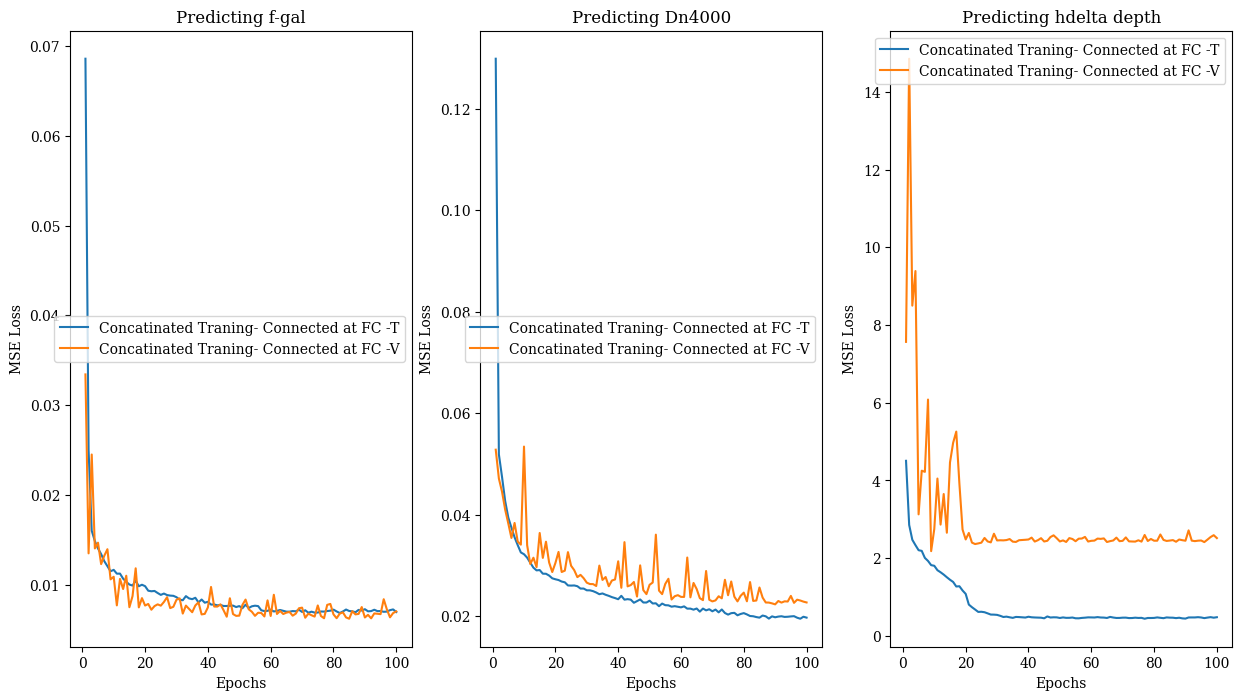

In [224]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M2P2_fgal_trainLossCurve)+1,1)


ax[0].plot(epoch_array,M2P2_fgal_trainLossCurve, label='Concatinated Traning- Connected at FC -T')
ax[1].plot(epoch_array,M2P2_dn4_trainLossCurve, label='Concatinated Traning- Connected at FC -T')
ax[2].plot(epoch_array,M2P2_hdelta_trainLossCurve, label='Concatinated Traning- Connected at FC -T')

ax[0].plot(epoch_array,M2P2_fgal_validLossCurve, label='Concatinated Traning- Connected at FC -V')
ax[1].plot(epoch_array,M2P2_dn4_validLossCurve, label='Concatinated Traning- Connected at FC -V')
ax[2].plot(epoch_array,M2P2_hdelta_validLossCurve, label='Concatinated Traning- Connected at FC -V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()


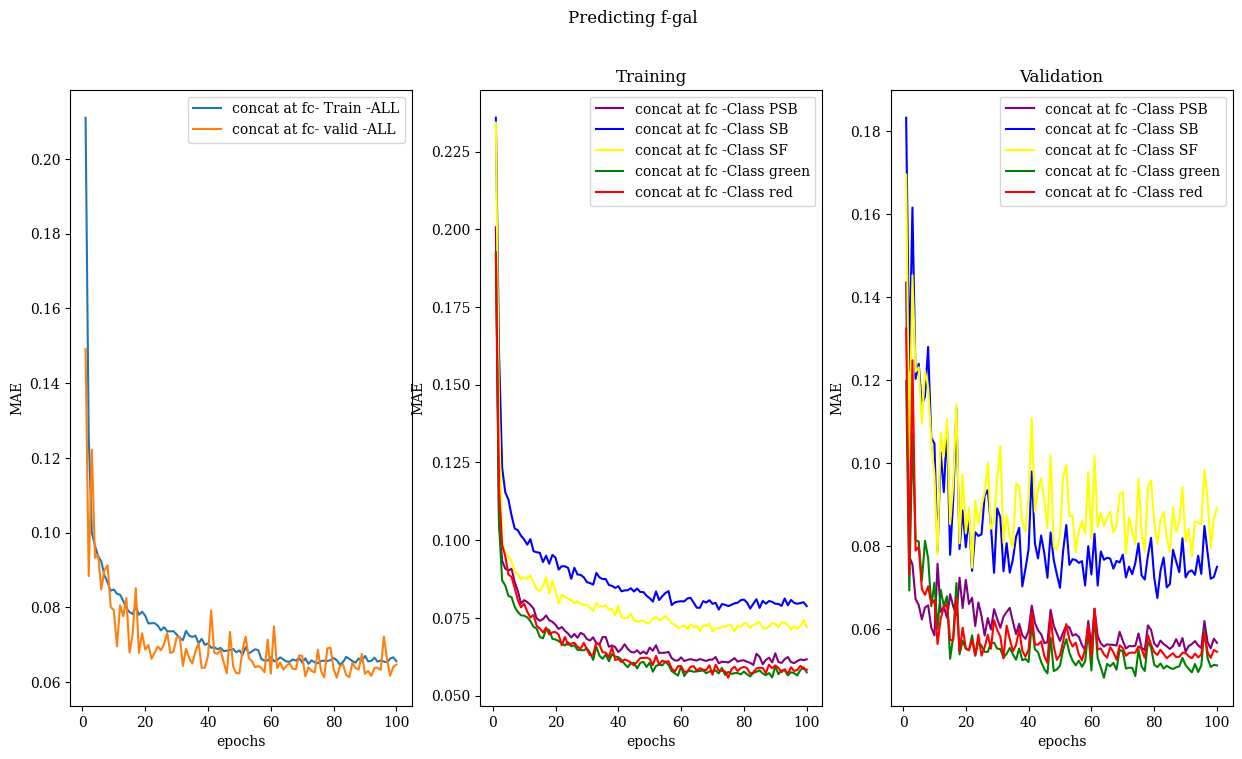

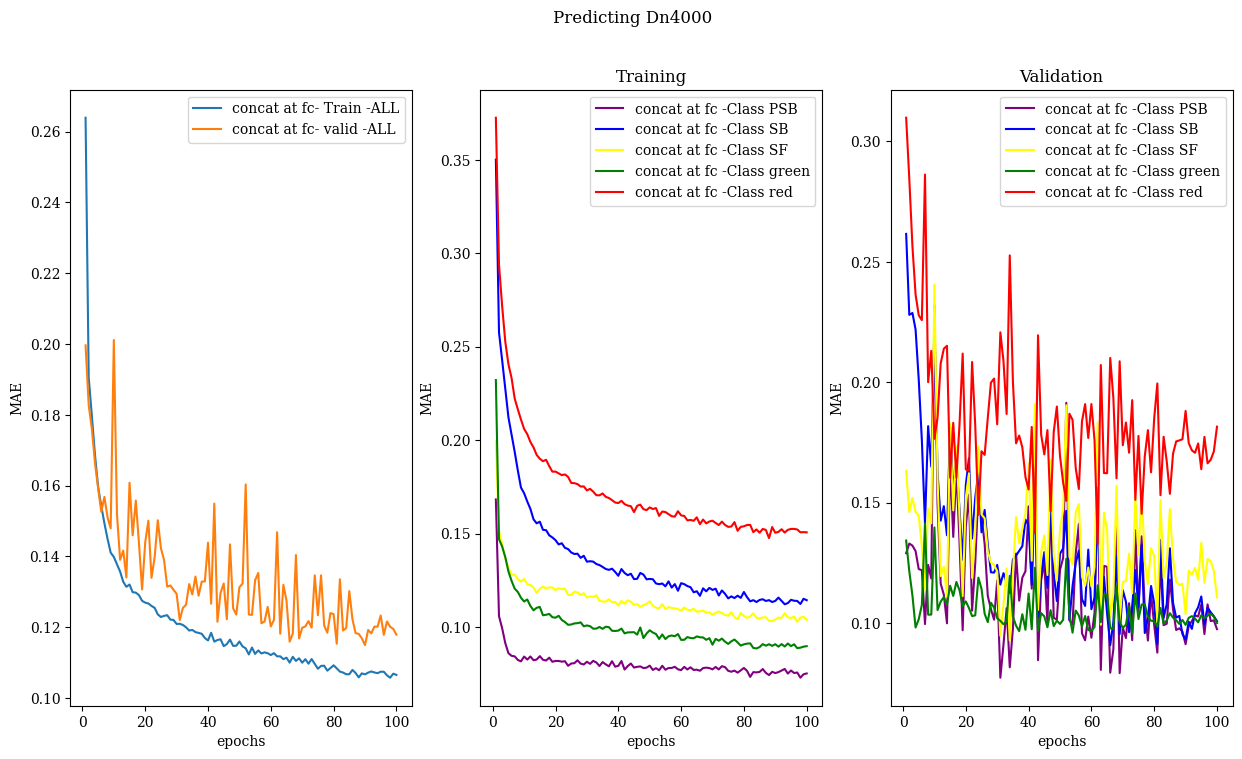

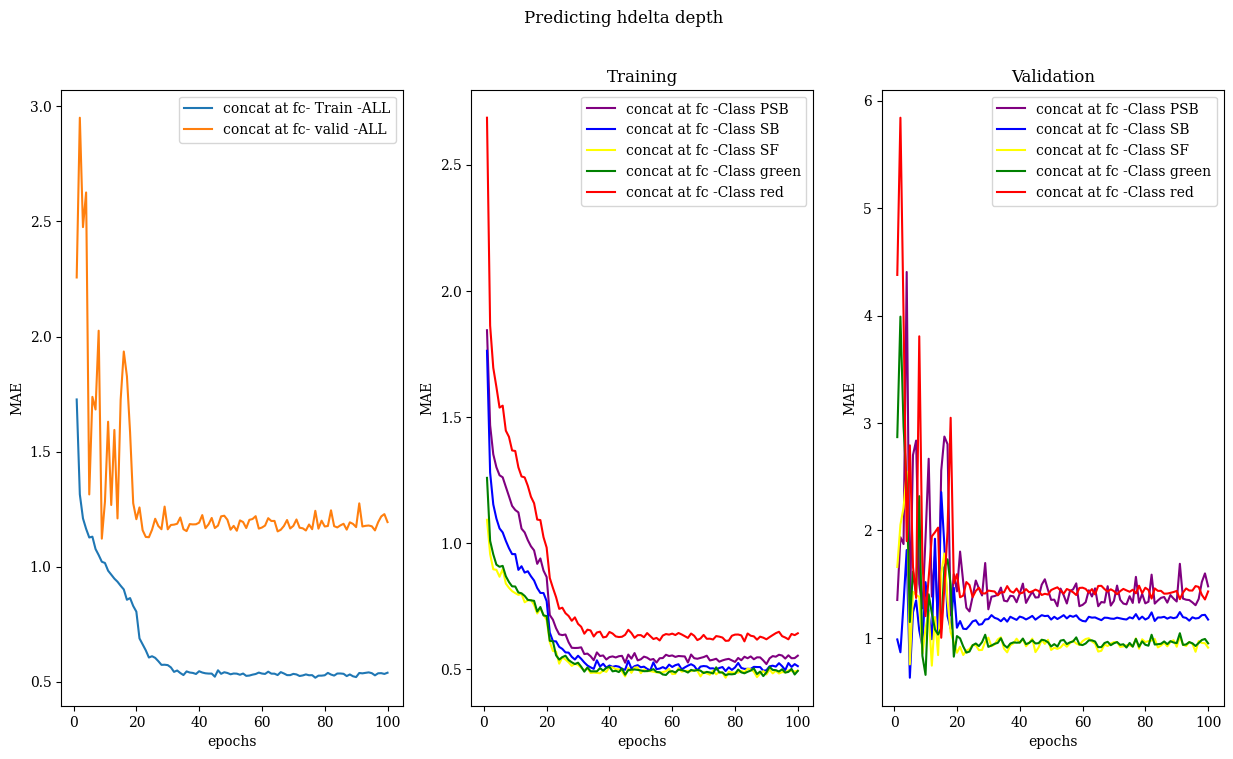

In [225]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)

epoch_array=np.arange(1,len(M2P2_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M2P2_fgal_MAETrainLossCurve[5], label='concat at fc- Train -ALL')
ax[0].plot(epoch_array,M2P2_fgal_MAEValidLossCurve[5], label='concat at fc- valid -ALL')

ax[1].plot(epoch_array,M2P2_fgal_MAETrainLossCurve[0], label='concat at fc -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M2P2_fgal_MAETrainLossCurve[1], label='concat at fc -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M2P2_fgal_MAETrainLossCurve[2], label='concat at fc -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M2P2_fgal_MAETrainLossCurve[3], label='concat at fc -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[1].plot(epoch_array,M2P2_fgal_MAETrainLossCurve[4], label='concat at fc -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M2P2_fgal_MAEValidLossCurve[0], label='concat at fc -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M2P2_fgal_MAEValidLossCurve[1], label='concat at fc -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M2P2_fgal_MAEValidLossCurve[2], label='concat at fc -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M2P2_fgal_MAEValidLossCurve[3], label='concat at fc -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[2].plot(epoch_array,M2P2_fgal_MAEValidLossCurve[4], label='concat at fc -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M2P2_dn4_MAETrainLossCurve[5], label='concat at fc- Train -ALL')
ax2[0].plot(epoch_array,M2P2_dn4_MAEValidLossCurve[5], label='concat at fc- valid -ALL')

ax2[1].plot(epoch_array,M2P2_dn4_MAETrainLossCurve[0], label='concat at fc -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M2P2_dn4_MAETrainLossCurve[1], label='concat at fc -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M2P2_dn4_MAETrainLossCurve[2], label='concat at fc -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M2P2_dn4_MAETrainLossCurve[3], label='concat at fc -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[1].plot(epoch_array,M2P2_dn4_MAETrainLossCurve[4], label='concat at fc -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M2P2_dn4_MAEValidLossCurve[0], label='concat at fc -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M2P2_dn4_MAEValidLossCurve[1], label='concat at fc -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M2P2_dn4_MAEValidLossCurve[2], label='concat at fc -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M2P2_dn4_MAEValidLossCurve[3], label='concat at fc -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[2].plot(epoch_array,M2P2_dn4_MAEValidLossCurve[4], label='concat at fc -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M2P2_hdelta_MAETrainLossCurve[5], label='concat at fc- Train -ALL')
ax3[0].plot(epoch_array,M2P2_hdelta_MAEValidLossCurve[5], label='concat at fc- valid -ALL')

ax3[1].plot(epoch_array,M2P2_hdelta_MAETrainLossCurve[0], label='concat at fc -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M2P2_hdelta_MAETrainLossCurve[1], label='concat at fc -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M2P2_hdelta_MAETrainLossCurve[2], label='concat at fc -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M2P2_hdelta_MAETrainLossCurve[3], label='concat at fc -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[1].plot(epoch_array,M2P2_hdelta_MAETrainLossCurve[4], label='concat at fc -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M2P2_hdelta_MAEValidLossCurve[0], label='concat at fc -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M2P2_hdelta_MAEValidLossCurve[1], label='concat at fc -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M2P2_hdelta_MAEValidLossCurve[2], label='concat at fc -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M2P2_hdelta_MAEValidLossCurve[3], label='concat at fc -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[2].plot(epoch_array,M2P2_hdelta_MAEValidLossCurve[4], label='concat at fc -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()

## Simultaneous traning

In [105]:
# train 3 models at the same time
def regressorTrainLoop(model, batch_data, batch_label,lossCalculator, optimiser):

    model.train()

    prediction=model(batch_data).squeeze()
    loss= lossCalculator(prediction, batch_label)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    epoch_train_loss = loss.item() # per batch

    return epoch_train_loss, prediction


def regressorValidationLoop(model, batch_data, batch_label,lossCalculator ):
    model.eval()
    with torch.no_grad():
        prediction=model(batch_data).squeeze()
        lossValue=lossCalculator(prediction, batch_label).item()


    return lossValue, prediction

def epochLoop(epochs, modelF_gal, model_dn4000, model_hdelta , traindataLoader, validdataLoader, loss_f_gal, loss_dn4, loss_hdel, optimiser_f_gal, optimiser_dn4, optimiser_hdel,scheduler_f_gal, scheduler_dn4, scheduler_hdel):
    #train on traning set epochs times
    M3_fgal_trainLossCurve=[]
    M3_fgal_validLossCurve=[]
    M3_dn4_trainLossCurve=[]
    M3_dn4_validLossCurve=[]
    M3_hdelta_trainLossCurve=[]
    M3_hdelta_validLossCurve=[]

    classdiffVSepoch_fgal=[[],[],[],[],[],[]]
    classdiffVSepoch_dn4=[[],[],[],[],[],[]]
    classdiffVSepoch_hdelta=[[],[],[],[],[],[]]

    classdiffVSepoch_valid_fgal=[[],[],[],[],[],[]]
    classdiffVSepoch_valid_dn4=[[],[],[],[],[],[]]
    classdiffVSepoch_valid_hdelta=[[],[],[],[],[],[]]

    allClass=[classdiffVSepoch_fgal, classdiffVSepoch_dn4, classdiffVSepoch_hdelta, classdiffVSepoch_valid_fgal, classdiffVSepoch_valid_dn4, classdiffVSepoch_valid_hdelta]

    for epoch in tqdm(range(1, epochs+1)):
        epoch_train_loss_F_gal=0
        epoch_valid_loss_F_gal=0

        epoch_train_loss_dn4=0
        epoch_valid_loss_dn4=0

        epoch_train_loss_hdel=0
        epoch_valid_loss_hdel=0

        allPredictionDiffs_fgal=np.array([[],[]])
        allPredictionDiffs_dn4=np.array([[],[]])
        allPredictionDiffs_hdelta=np.array([[],[]])

        allPredictionDiffs_valid_fgal=np.array([[],[]])
        allPredictionDiffs_valid_dn4=np.array([[],[]])
        allPredictionDiffs_valid_hdelta=np.array([[],[]])

        for batch_flux, batch_f_gal, batch_hue , batch_dn4, batch_hdel  in traindataLoader:

            batch_flux=batch_flux.unsqueeze(1)
            batch_flux=batch_flux.to(device)
            batch_f_gal=batch_f_gal.to(device)
            batch_dn4 =batch_dn4.to(device)
            batch_hdel=batch_hdel.to(device)

            temp1, f_galPrediction =regressorTrainLoop(modelF_gal , batch_flux, batch_f_gal, loss_f_gal, optimiser_f_gal)

            # edit the batch_flux to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux = torch.cat((batch_flux, newChannel), dim=1)  # contains new channel per input with predicted f_gal

            predictionDiff=abs(f_galPrediction - batch_f_gal)

            allPredictionDiffs_fgal=[np.append(allPredictionDiffs_fgal[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_fgal[1]]
            allPredictionDiffs_fgal=[allPredictionDiffs_fgal[0],np.append(allPredictionDiffs_fgal[1], batch_hue.cpu().numpy())]


            temp2, dn4Prediction= regressorTrainLoop(model_dn4000, modified_batch_flux, batch_dn4, loss_dn4, optimiser_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_2 = torch.cat((modified_batch_flux, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            predictionDiff=abs(dn4Prediction - batch_dn4)
            allPredictionDiffs_dn4=[np.append(allPredictionDiffs_dn4[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_dn4[1]]
            allPredictionDiffs_dn4=[allPredictionDiffs_dn4[0],np.append(allPredictionDiffs_dn4[1], batch_hue.cpu().numpy())]

            temp3, hdeltaPrediction = regressorTrainLoop(model_hdelta, modified_batch_flux_2, batch_hdel, loss_hdel, optimiser_hdel)

            predictionDiff=abs(hdeltaPrediction - batch_hdel)
            allPredictionDiffs_hdelta=[np.append(allPredictionDiffs_hdelta[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_hdelta[1]]
            allPredictionDiffs_hdelta=[allPredictionDiffs_hdelta[0],np.append(allPredictionDiffs_hdelta[1], batch_hue.cpu().numpy())]

            epoch_train_loss_F_gal+=temp1
            epoch_train_loss_dn4+=temp2
            epoch_train_loss_hdel+=temp3



        for batch_flux_V, batch_f_gal_V, batch_hue , batch_dn4_V, batch_hdel_V in validdataLoader:

            batch_flux_V=batch_flux_V.unsqueeze(1)
            batch_flux_V=batch_flux_V.to(device)
            batch_f_gal_V=batch_f_gal_V.to(device)
            batch_dn4_V=batch_dn4_V.to(device)
            batch_hdel_V=batch_hdel_V.to(device)


            temp1, f_galPrediction=regressorValidationLoop(modelF_gal,batch_flux_V, batch_f_gal_V, loss_f_gal)

            # edit the batch_flux_V to have another channel before adding to classifier
                # need to detach from gradients so that classifier doesn't backpropagate the loss and change the weights of the regressor, then
                # unsqueeze twice so the array is 3D when brodcasting with the batch flux
            expandablePrediction=f_galPrediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V = torch.cat((batch_flux_V, newChannel), dim=1) # contains new channel per input with predicted f_gal

            predictionDiff=abs(f_galPrediction - batch_f_gal_V)
            allPredictionDiffs_valid_fgal=[np.append(allPredictionDiffs_valid_fgal[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_fgal[1]]
            allPredictionDiffs_valid_fgal=[allPredictionDiffs_valid_fgal[0],np.append(allPredictionDiffs_valid_fgal[1], batch_hue.cpu().numpy())]

            temp2, dn4Prediction=regressorValidationLoop(model_dn4000,modified_batch_flux_V, batch_dn4_V, loss_dn4)

            expandablePrediction=dn4Prediction.detach().unsqueeze(1).unsqueeze(1)
            newChannel = expandablePrediction.expand(-1, 1, 1890).to(device)
            modified_batch_flux_V_2 = torch.cat((modified_batch_flux_V, newChannel), dim=1)  # contains new channel per input with predicted dn4000

            predictionDiff=abs(dn4Prediction - batch_dn4_V)
            allPredictionDiffs_valid_dn4=[np.append(allPredictionDiffs_valid_dn4[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_dn4[1]]
            allPredictionDiffs_valid_dn4=[allPredictionDiffs_valid_dn4[0],np.append(allPredictionDiffs_valid_dn4[1], batch_hue.cpu().numpy())]

            temp3, hdelPrediction = regressorValidationLoop(model_hdelta, modified_batch_flux_V_2, batch_hdel_V, loss_hdel)

            predictionDiff=abs(hdelPrediction - batch_hdel_V)
            allPredictionDiffs_valid_hdelta=[np.append(allPredictionDiffs_valid_hdelta[0], predictionDiff.cpu().detach().numpy()),allPredictionDiffs_valid_hdelta[1]]
            allPredictionDiffs_valid_hdelta=[allPredictionDiffs_valid_hdelta[0],np.append(allPredictionDiffs_valid_hdelta[1], batch_hue.cpu().numpy())]

            epoch_valid_loss_F_gal+=temp1
            epoch_valid_loss_dn4+=temp2
            epoch_valid_loss_hdel+=temp3


        allPredictionDiffs=[allPredictionDiffs_fgal, allPredictionDiffs_dn4,allPredictionDiffs_hdelta,allPredictionDiffs_valid_fgal,allPredictionDiffs_valid_dn4,allPredictionDiffs_valid_hdelta]

        index=0
        for i in allPredictionDiffs:
            class0idx=np.where(i[1] == 0)[0]
            class1idx=np.where(i[1] == 1)[0]
            class2idx=np.where(i[1] == 2)[0]
            class3idx=np.where(i[1] == 3)[0]
            class4idx=np.where(i[1] == 4)[0]

            allClass[index]=[np.append(allClass[index][0],np.sum(i[0][class0idx])/len(class0idx)),allClass[index][1],allClass[index][2],allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],np.append(allClass[index][1],np.sum(i[0][class1idx])/len(class1idx)),allClass[index][2],allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],np.append(allClass[index][2],np.sum(i[0][class2idx])/len(class2idx)),allClass[index][3],allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],np.append(allClass[index][3],np.sum(i[0][class3idx])/len(class3idx)),allClass[index][4],allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],np.append(allClass[index][4],np.sum(i[0][class4idx])/len(class4idx)),allClass[index][5]]
            allClass[index]=[allClass[index][0],allClass[index][1],allClass[index][2],allClass[index][3],allClass[index][4],np.append(allClass[index][5],np.sum(i[0])/len(i[0]))]

            index+=1


        epoch_train_loss_F_gal/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_F_gal/=len(validdataLoader) # average over number of batches

        epoch_train_loss_dn4/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_dn4/=len(validdataLoader) # average over number of batches

        epoch_train_loss_hdel/=len(traindataLoader) # average over number of batches
        epoch_valid_loss_hdel/=len(validdataLoader) # average over number of batches


        scheduler_f_gal.step(epoch_valid_loss_F_gal)
        scheduler_dn4.step(epoch_valid_loss_dn4)
        scheduler_hdel.step(epoch_valid_loss_hdel)


        M3_fgal_trainLossCurve.append(epoch_train_loss_F_gal)
        M3_fgal_validLossCurve.append(epoch_valid_loss_F_gal)
        M3_dn4_trainLossCurve.append(epoch_train_loss_dn4)
        M3_dn4_validLossCurve.append(epoch_valid_loss_dn4)
        M3_hdelta_trainLossCurve.append(epoch_train_loss_hdel)
        M3_hdelta_validLossCurve.append(epoch_valid_loss_hdel)


        epoch_train_loss_F_gal=round(epoch_train_loss_F_gal, 10)
        epoch_valid_loss_F_gal=round(epoch_valid_loss_F_gal, 10)
        epoch_train_loss_dn4= round(epoch_train_loss_dn4, 10)
        epoch_valid_loss_dn4= round(epoch_valid_loss_dn4, 10)
        epoch_train_loss_hdel=round(epoch_train_loss_hdel, 10)
        epoch_valid_loss_hdel=round(epoch_valid_loss_hdel, 10)


        # Printing accuracy values ----------
        if epochs > 21:
            if epoch % 5 == 0:
                print('--------------Epoch Number: ', epoch,'--------------')
                print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
                print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
                print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])
        else:
            print('---------------Epoch Number: ', epoch,'--------------')
            print('Model-F_gal | Train loss:', epoch_train_loss_F_gal ,'Validation Loss:',epoch_valid_loss_F_gal,'lr:',scheduler_f_gal.get_last_lr()[0])
            print('Model-Dn4000| Train loss:', epoch_train_loss_dn4 ,'Validation Loss:',epoch_valid_loss_dn4, 'lr:',scheduler_dn4.get_last_lr()[0])
            print('Model-Hdelta| Train loss:', epoch_train_loss_hdel ,'Validation Loss:',epoch_valid_loss_hdel, 'lr:', scheduler_hdel.get_last_lr()[0])


    return M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, allClass

In [111]:
blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[10,20,40,80] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]

model_fgal_simul=fullResNetModel50(1, blockList, channelList,1, False, stride, chainNumber=0)
model_dn4_simul=fullResNetModel50(2, blockList, channelList,1, False, stride, chainNumber=0)


blockList=['placeHolder',2,2,2] # blocks in middle layer
channelList=[20,40,80,160] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,2]
model_hdel_simul=fullResNetModel50(3, blockList, channelList,1, False, stride, chainNumber=0)

loss_f_gal= nn.MSELoss()
loss_dn4= nn.MSELoss()
loss_hdel= nn.MSELoss()

optimiser_f_gal= torch.optim.SGD(model_fgal_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_dn4= torch.optim.SGD(model_dn4_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
optimiser_hdel= torch.optim.SGD(model_hdel_simul.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)

lrScheduler_f_gal=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_f_gal, mode='min')
lrScheduler_dn4=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_dn4, mode='min')
lrScheduler_hdel=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser_hdel, mode='min')


# train
model_fgal_simul.to(device)
model_dn4_simul.to(device)
model_hdel_simul.to(device)
epochs=100

M3_fgal_trainLossCurve, M3_fgal_validLossCurve ,M3_dn4_trainLossCurve ,M3_dn4_validLossCurve ,M3_hdelta_trainLossCurve ,M3_hdelta_validLossCurve, ALLMAE=epochLoop(epochs, model_fgal_simul, model_dn4_simul, model_hdel_simul,
          train_data_loader, valid_data_loader,
          loss_f_gal, loss_dn4, loss_hdel,
          optimiser_f_gal, optimiser_dn4, optimiser_hdel,
          lrScheduler_f_gal, lrScheduler_dn4, lrScheduler_hdel) # add early stopping on hdel val error

  0%|          | 0/100 [00:00<?, ?it/s]

--------------Epoch Number:  5 --------------
Model-F_gal | Train loss: 0.0116925473 Validation Loss: 0.012893152 lr: 0.001
Model-Dn4000| Train loss: 0.0372646947 Validation Loss: 0.0389878992 lr: 0.001
Model-Hdelta| Train loss: 2.1244403365 Validation Loss: 2.7949091196 lr: 0.001
--------------Epoch Number:  10 --------------
Model-F_gal | Train loss: 0.0107245894 Validation Loss: 0.0135225961 lr: 0.001
Model-Dn4000| Train loss: 0.030502884 Validation Loss: 0.0270505575 lr: 0.001
Model-Hdelta| Train loss: 1.7217403406 Validation Loss: 1.5381526351 lr: 0.001
--------------Epoch Number:  15 --------------
Model-F_gal | Train loss: 0.0099347821 Validation Loss: 0.0099794976 lr: 0.001
Model-Dn4000| Train loss: 0.0276414495 Validation Loss: 0.0237085167 lr: 0.001
Model-Hdelta| Train loss: 1.4721444642 Validation Loss: 1.7550848722 lr: 0.001
--------------Epoch Number:  20 --------------
Model-F_gal | Train loss: 0.0096918229 Validation Loss: 0.0103490467 lr: 0.001
Model-Dn4000| Train loss:

#### loss curves

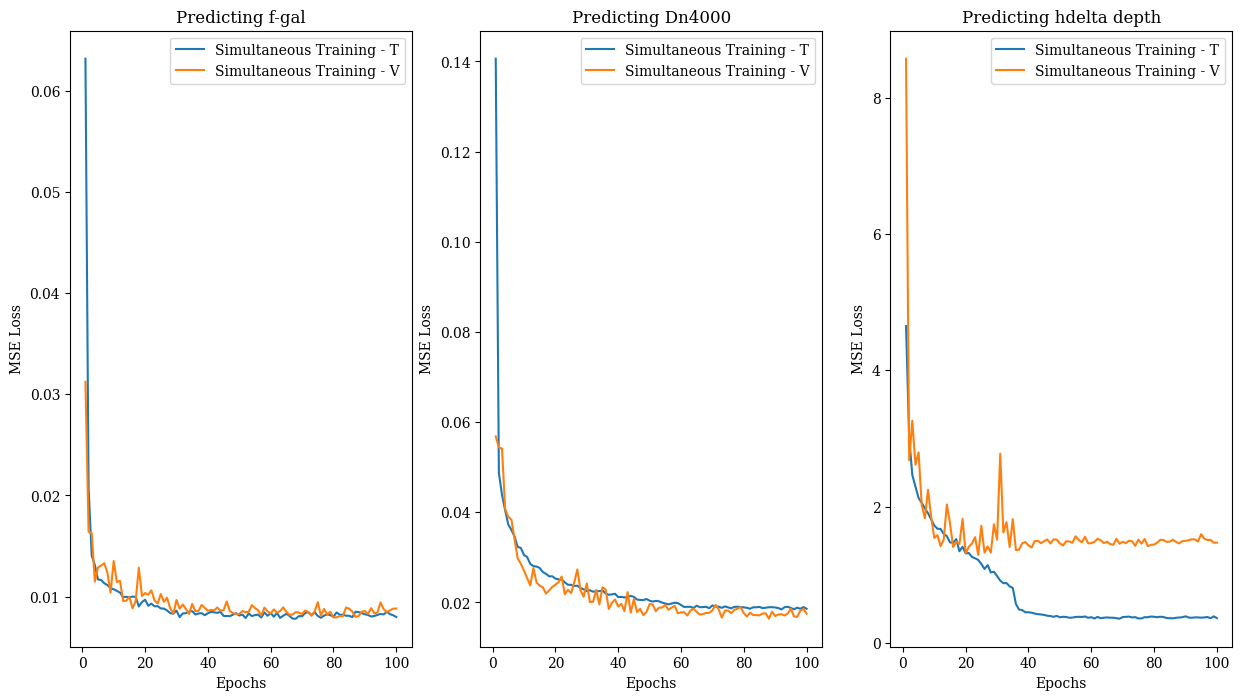

In [114]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_trainLossCurve, label='Simultaneous Training - T')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve, label='Simultaneous Training - T')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve, label='Simultaneous Training - T')

ax[0].plot(epoch_array,M3_fgal_validLossCurve, label='Simultaneous Training - V')
ax[1].plot(epoch_array,M3_dn4_validLossCurve, label='Simultaneous Training - V')
ax[2].plot(epoch_array,M3_hdelta_validLossCurve, label='Simultaneous Training - V')

ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax[0].set_ylabel('MSE Loss')
ax[1].set_ylabel('MSE Loss')
ax[2].set_ylabel('MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()


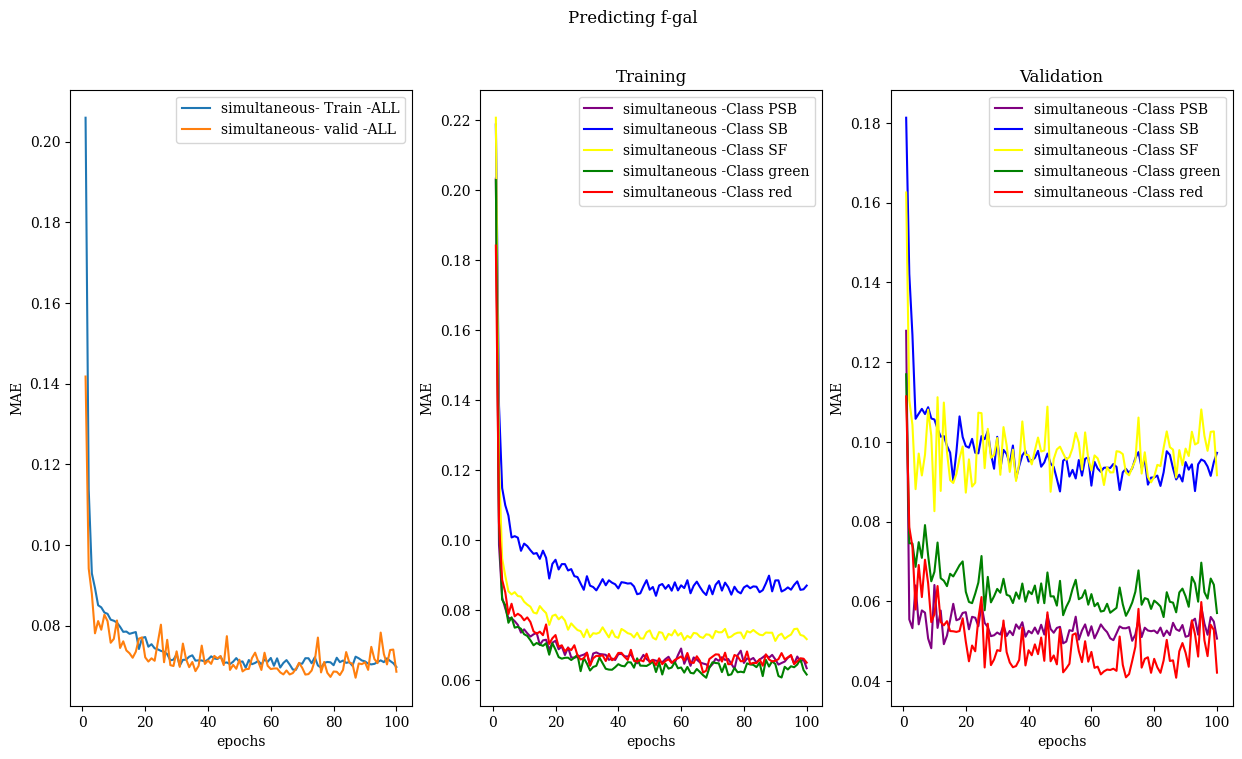

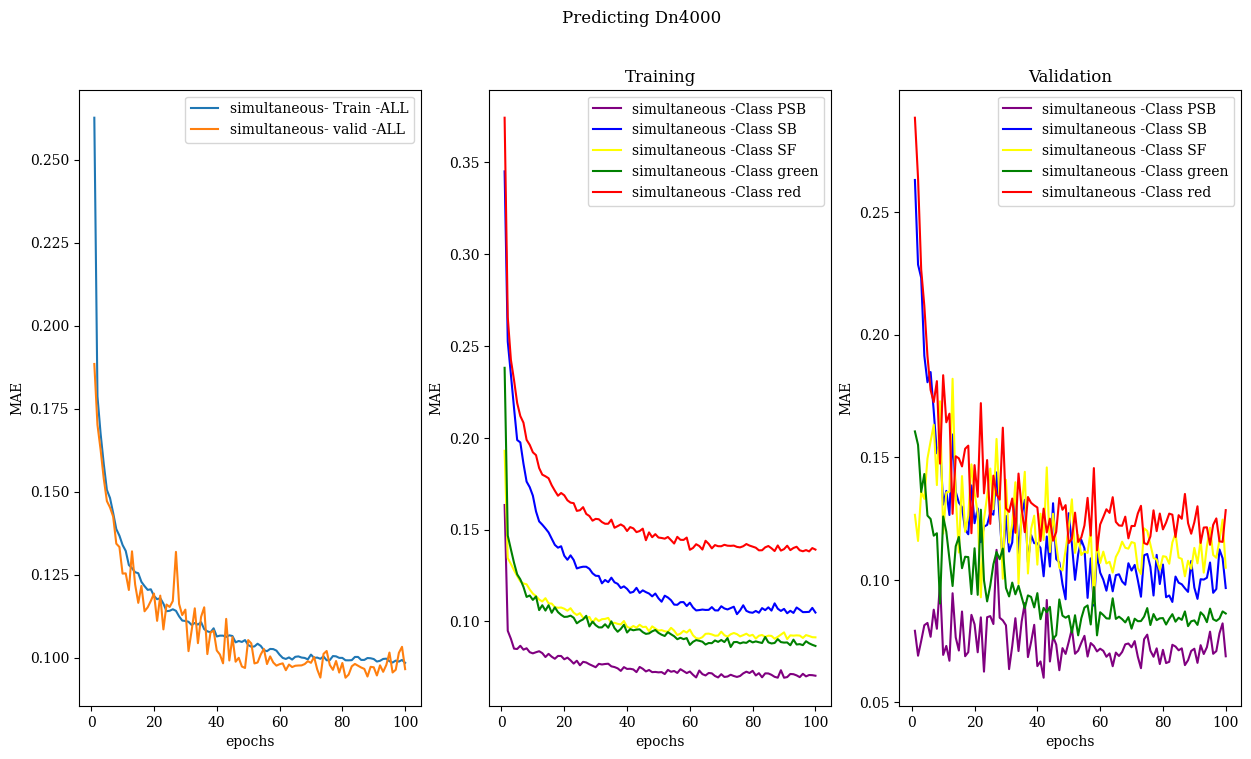

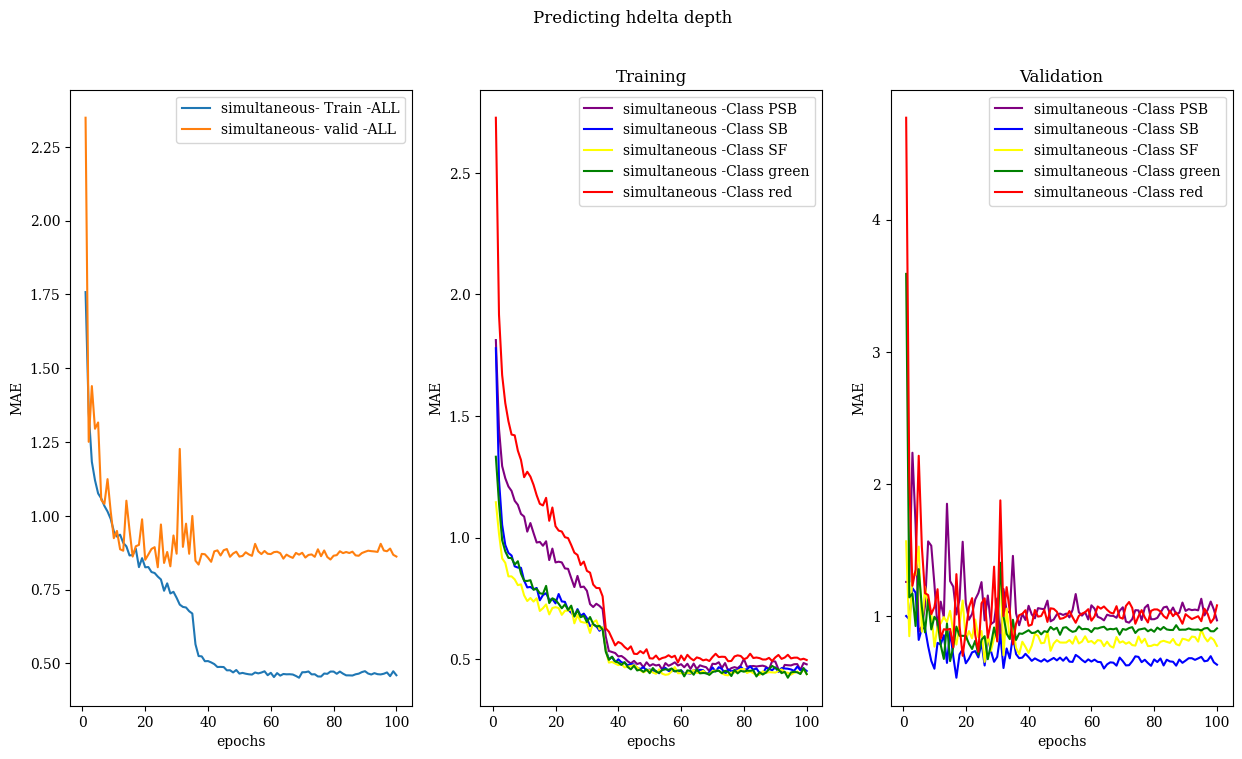

In [115]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig2, ax2=plt.subplots(figsize=(15,8), ncols=3)
fig3, ax3=plt.subplots(figsize=(15,8), ncols=3)


M3_fgal_MAETrainLossCurve=ALLMAE[0]
M3_fgal_MAEValidLossCurve=ALLMAE[3]

M3_dn4_MAETrainLossCurve=ALLMAE[1]
M3_dn4_MAEValidLossCurve=ALLMAE[4]

M3_hdelta_MAETrainLossCurve=ALLMAE[2]
M3_hdelta_MAEValidLossCurve=ALLMAE[5]

epoch_array=np.arange(1,len(M3_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M3_fgal_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax[0].plot(epoch_array,M3_fgal_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[1].plot(epoch_array,M3_fgal_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax[2].plot(epoch_array,M3_fgal_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')



ax2[0].plot(epoch_array,M3_dn4_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax2[0].plot(epoch_array,M3_dn4_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[1].plot(epoch_array,M3_dn4_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax2[2].plot(epoch_array,M3_dn4_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


ax3[0].plot(epoch_array,M3_hdelta_MAETrainLossCurve[5], label='simultaneous- Train -ALL')
ax3[0].plot(epoch_array,M3_hdelta_MAEValidLossCurve[5], label='simultaneous- valid -ALL')

ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[1].plot(epoch_array,M3_hdelta_MAETrainLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')

ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[0], label='simultaneous -Class '+str(le.inverse_transform([0])[0]), color='purple')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[1], label='simultaneous -Class '+str(le.inverse_transform([1])[0]), color='blue')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[2], label='simultaneous -Class '+str(le.inverse_transform([2])[0]), color='yellow')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[3], label='simultaneous -Class '+str(le.inverse_transform([3])[0]), color= 'green')
ax3[2].plot(epoch_array,M3_hdelta_MAEValidLossCurve[4], label='simultaneous -Class '+str(le.inverse_transform([4])[0]), color='red')


fig.suptitle('Predicting f-gal')
fig2.suptitle('Predicting Dn4000')
fig3.suptitle('Predicting hdelta depth')


ax[0].set_xlabel('epochs')
ax[0].set_ylabel('MAE')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('MAE')
ax[1].set_title('Training')
ax[2].set_xlabel('epochs')
ax[2].set_ylabel('MAE')
ax[2].set_title('Validation')
ax[0].legend()
ax[1].legend()
ax[2].legend()


ax2[0].set_xlabel('epochs')
ax2[0].set_ylabel('MAE')
ax2[1].set_xlabel('epochs')
ax2[1].set_ylabel('MAE')
ax2[1].set_title('Training')
ax2[2].set_xlabel('epochs')
ax2[2].set_ylabel('MAE')
ax2[2].set_title('Validation')
ax2[0].legend()
ax2[1].legend()
ax2[2].legend()


ax3[0].set_xlabel('epochs')
ax3[0].set_ylabel('MAE')
ax3[1].set_xlabel('epochs')
ax3[1].set_ylabel('MAE')
ax3[1].set_title('Training')
ax3[2].set_xlabel('epochs')
ax3[2].set_ylabel('MAE')
ax3[2].set_title('Validation')
ax3[0].legend()
ax3[1].legend()
ax3[2].legend()

## Combined Loss Graphs

- f-gal for each method should more or less be the same, it is the same method of input data just small variation in intial randomness that should disappear after enough epochs

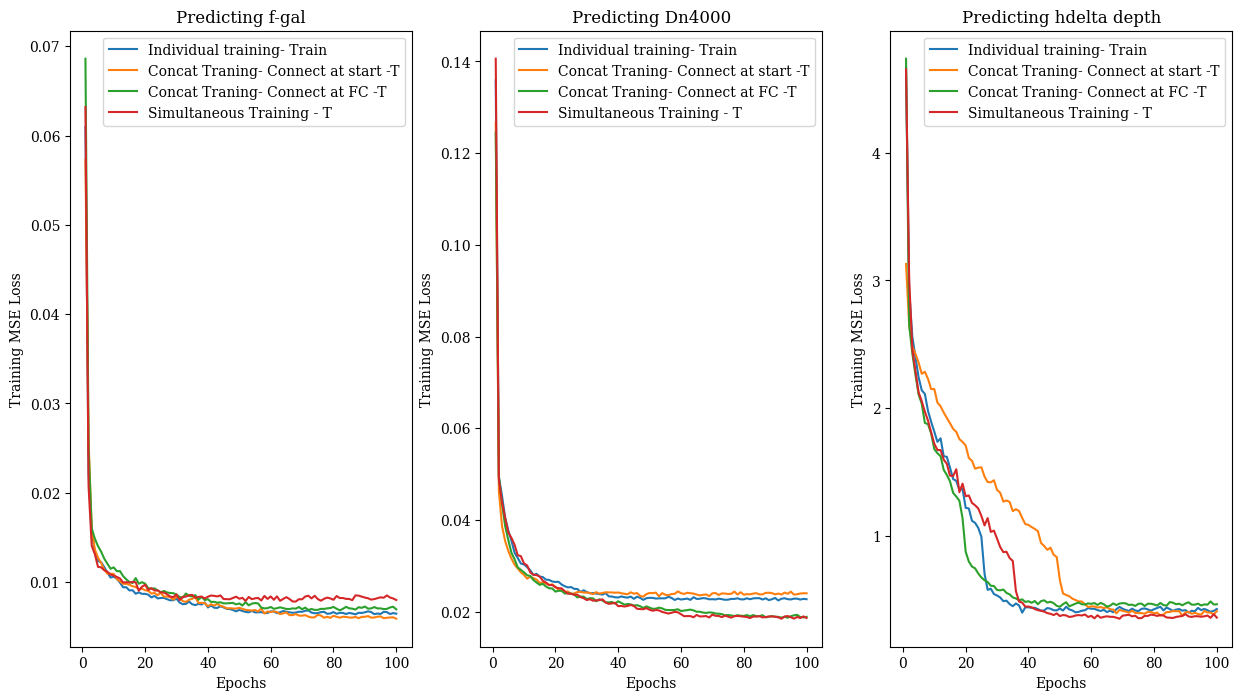

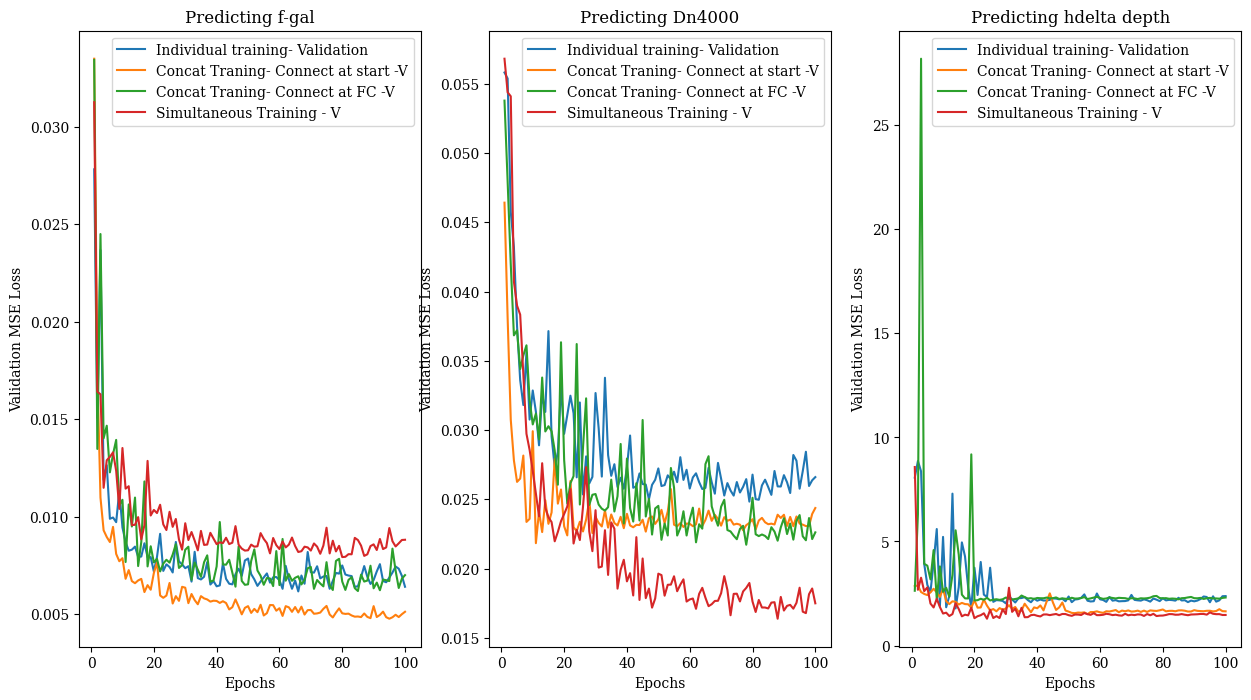

In [203]:
fig, ax=plt.subplots(figsize=(15,8), ncols=3)
fig1, ax1=plt.subplots(figsize=(15,8), ncols=3)

epoch_array=np.arange(1,len(M1_fgal_trainLossCurve)+1,1)

ax[0].plot(epoch_array,M1_fgal_trainLossCurve   , label='Individual training- Train')
ax[1].plot(epoch_array,M1_dn4_trainLossCurve    , label='Individual training- Train')
ax[2].plot(epoch_array,M1_hdelta_trainLossCurve , label='Individual training- Train')

ax1[0].plot(epoch_array,M1_fgal_validLossCurve  , label='Individual training- Validation')
ax1[1].plot(epoch_array,M1_dn4_validLossCurve   , label='Individual training- Validation')
ax1[2].plot(epoch_array,M1_hdelta_validLossCurve, label='Individual training- Validation')


ax[0].plot(epoch_array,M2_fgal_trainLossCurve, label='Concat Traning- Connect at start -T')
ax[1].plot(epoch_array,M2_dn4_trainLossCurve, label='Concat Traning- Connect at start -T')
ax[2].plot(epoch_array,M2_hdelta_trainLossCurve, label='Concat Traning- Connect at start -T')

ax1[0].plot(epoch_array,M2_fgal_validLossCurve, label='Concat Traning- Connect at start -V')
ax1[1].plot(epoch_array,M2_dn4_validLossCurve, label='Concat Traning- Connect at start -V')
ax1[2].plot(epoch_array,M2_hdelta_validLossCurve, label='Concat Traning- Connect at start -V')


ax[0].plot(epoch_array,M2P2_fgal_trainLossCurve, label='Concat Traning- Connect at FC -T')
ax[1].plot(epoch_array,M2P2_dn4_trainLossCurve, label='Concat Traning- Connect at FC -T')
ax[2].plot(epoch_array,M2P2_hdelta_trainLossCurve, label='Concat Traning- Connect at FC -T')

ax1[0].plot(epoch_array,M2P2_fgal_validLossCurve, label='Concat Traning- Connect at FC -V')
ax1[1].plot(epoch_array,M2P2_dn4_validLossCurve, label='Concat Traning- Connect at FC -V')
ax1[2].plot(epoch_array,M2P2_hdelta_validLossCurve, label='Concat Traning- Connect at FC -V')


ax[0].plot(epoch_array,M3_fgal_trainLossCurve, label='Simultaneous Training - T')
ax[1].plot(epoch_array,M3_dn4_trainLossCurve, label='Simultaneous Training - T')
ax[2].plot(epoch_array,M3_hdelta_trainLossCurve, label='Simultaneous Training - T')

ax1[0].plot(epoch_array,M3_fgal_validLossCurve, label='Simultaneous Training - V')
ax1[1].plot(epoch_array,M3_dn4_validLossCurve, label='Simultaneous Training - V')
ax1[2].plot(epoch_array,M3_hdelta_validLossCurve, label='Simultaneous Training - V')

#---------------labels
ax[0].set_title('Predicting f-gal')
ax[1].set_title('Predicting Dn4000')
ax[2].set_title('Predicting hdelta depth')

ax1[0].set_title('Predicting f-gal')
ax1[1].set_title('Predicting Dn4000')
ax1[2].set_title('Predicting hdelta depth')

ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')

ax1[0].set_xlabel('Epochs')
ax1[1].set_xlabel('Epochs')
ax1[2].set_xlabel('Epochs')

ax[0].set_ylabel('Training MSE Loss')
ax[1].set_ylabel('Training MSE Loss')
ax[2].set_ylabel('Training MSE Loss')

ax1[0].set_ylabel('Validation MSE Loss')
ax1[1].set_ylabel('Validation MSE Loss')
ax1[2].set_ylabel('Validation MSE Loss')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax1[0].legend()
ax1[1].legend()
ax1[2].legend()

In [ ]:
fig, ax=plt.subplots(figsize=(15,20), nrows=5)

for i in range(5):

    ax[i].plot(epoch_array,M1_hdelta_MAEValidLossCurve[i], label='indiv -Class '+str(le.inverse_transform([i])[0]))
    ax[i].plot(epoch_array,M2_hdelta_MAEValidLossCurve[i], label='Concat at start -Class '+str(le.inverse_transform([i])[0]))
    ax[i].plot(epoch_array,M2P2_hdelta_MAEValidLossCurve[i], label='Concat at fc -Class '+str(le.inverse_transform([i])[0]))
    ax[i].plot(epoch_array,M3_hdelta_MAEValidLossCurve[i], label='Simultaneous -Class '+str(le.inverse_transform([i])[0]))

    ax[i].legend()
    ax[i].set_title('Predicting hdelta for '+str(le.inverse_transform([i])[0]))
    ax[i].set_ylabel('MAE')


## Graphing Prediction vs Truth

- indiv  [DONE]
    - input required: just flux array

        - model_fgal_indv
        - model_dn4_indv
        - model_hdelta_indv


- Concat- at start [DONE]
    - input required: just flux array + prediction from previous models as new channel

        - model_fgal_Version2
        - model_dn4000_Version2
        - model_hdelta_Version2

- concat - at fc
    -  input required: just flux array + prediction from previous models as new channel
        - model_fgal_Version3
        - model_dn4000_Version3
        - model_hdelta_Version3


-  Simul
    -  input required: just flux array + prediction from previous models as new channel
        - model_fgal_simul
        - model_dn4_simul
        - model_hdel_simul

### graphing functions




In [127]:
#graph
def dataFor_graphPredictionTruth(model, train_data_loader, valid_data_loder, predictingWhat):
    # returns model predictions on training and validation data
    model.eval()
    predict_train=np.array([])
    truth_train=np.array([])
    diff_train=np.array([])
    hue_train=np.array([])

    predict_val=np.array([])
    truth_val=np.array([])
    diff_val=np.array([])
    hue_val=np.array([])

    for flux, f_gal, dn4000, hdelta, gal_type_code in train_data_loader:
        with torch.no_grad():
            trial_batch_p=flux.to(device)
            trial_batch_hue=gal_type_code

            if predictingWhat == 'f-gal':
                trial_batch_t=f_gal.to(device)
            elif  predictingWhat == 'dn4000' :
                trial_batch_t=dn4000.to(device)
            elif predictingWhat == 'hdelta':
                trial_batch_t=hdelta.to(device)


            if trial_batch_p.shape[1] not in [1,2,3]:
                trial_batch_p=trial_batch_p.unsqueeze(1)

            predict_train=np.append(predict_train, model(trial_batch_p).cpu().squeeze().detach().numpy())
        truth_train=np.append(truth_train, trial_batch_t.cpu().detach().numpy())
        hue_train=np.append(hue_train, trial_batch_hue.cpu().detach().numpy())

    diff_train=np.append(diff_train,truth_train-predict_train)


    for flux, f_gal, dn4000, hdelta, gal_type_code in valid_data_loder:
        with torch.no_grad():
            trial_batch_p=flux.to(device)
            trial_batch_hue=gal_type_code

            if predictingWhat == 'f-gal':
                trial_batch_t=f_gal.to(device)
            elif  predictingWhat == 'dn4000' :
                trial_batch_t=dn4000.to(device)
            elif predictingWhat == 'hdelta':
                trial_batch_t=hdelta.to(device)

            if trial_batch_p.shape[1] not in [1,2,3]:
                trial_batch_p=trial_batch_p.unsqueeze(1)

            predict_val=np.append(predict_val,model(trial_batch_p).cpu().squeeze().detach().numpy())
        truth_val=np.append(truth_val,trial_batch_t.cpu().detach().numpy())
        hue_val=np.append(hue_val, trial_batch_hue.cpu().detach().numpy())

    diff_val=truth_val-predict_val


    return [predict_train,truth_train,diff_train, hue_train], [predict_val,truth_val,diff_val,hue_val]

In [183]:
def graphPredictionTruth(predict_train, truth_train, diff_train, hue_train,predict_val, truth_val, diff_val, hue_val, attempt,ax, hueBool, le):
    # uses prediction from dataFor_graphPredictionTruth_alex to plot graphs
    ax[0].set_yticklabels([])
    ax[0].set_xticklabels([])
    ax[1].set_yticklabels([])
    ax[1].set_xticklabels([])

    frame2=fig.add_axes((.05,.25,.45,.75)) # splits graphs into 4 graphs with bottom 2 graphs being smaller
    frame1=fig.add_axes((.05,.01,.45,.25))

    frame4=fig.add_axes((.54,.25,.45,.75))
    frame3=fig.add_axes((.54,.01,.45,.25))

    trainR2=r2_score(truth_train, predict_train)
    valR2=r2_score(truth_val, predict_val)

    # r2X=max(truth_train)*0.8
    # r2Y=min(predict_train)*1.05
    # frame2.text(r2X,r2Y, r'$r^2=$ '+str(round(trainR2,3)), fontsize=20)
    # r2X=min(truth_val)*1.05
    # r2Y=max(predict_val)*0.95
    # frame4.text(r2X,r2Y, r'$r^2=$ '+str(round(valR2,3)), fontsize=20)

    r2X=min(truth_train)*1.05
    r2Y=max(predict_train)*0.95
    frame2.text(r2X,r2Y, r'$r^2=$ '+str(round(trainR2,3)), fontsize=20)
    r2X=min(truth_val)*1.05
    r2Y=max(predict_val)*0.95
    frame4.text(r2X,r2Y, r'$r^2=$ '+str(round(valR2,3)), fontsize=20)

    # creates 2D array of training results and validation results
    t = np.array(list(zip(predict_train, truth_train, diff_train, hue_train)), dtype = [('predict', float), ('truth', float), ('diff', float), ('gal_type', int)])
    if hueBool == False:
        # doesn't colour based on gal_type
        frame2.scatter(x=t['truth'], y=t['predict'], c='blue', alpha=0.2, label='Data')
        frame1.scatter(x=t['truth'], y=t['diff'], c='blue', alpha=0.2)
    else:
        # colours based on gal type
        df = pd.DataFrame.from_records(t)
        df['gal_type']=le.inverse_transform(df['gal_type'])
        sns.scatterplot(data=df, x='truth', y='predict', hue='gal_type', ax=frame2, alpha=0.2, hue_order=['SB', 'SF', 'green','red', 'PSB'])
        sns.scatterplot(data=df, x='truth', y='diff',hue='gal_type', ax=frame1, alpha=0.2,hue_order=['SB', 'SF', 'green','red', 'PSB'])


    minTruth=min(truth_train)
    maxTruth=max(truth_train)
    frame2.plot([minTruth,maxTruth],[minTruth,maxTruth], c='orange',label='Truth=Prediction')
    frame1.plot([minTruth,maxTruth],[0,0], c='orange')
    #frame1.set_ylim(-0.099,0.099)

    frame1.set_xlabel('True', size=20)
    frame2.set_ylabel('Predicted ', size=20)
    frame1.set_ylabel('Difference', size=16)
    frame2.set_title(attempt+' Train Set', fontsize=34)

    t = np.array(list(zip(predict_val, truth_val, diff_val, hue_val)), dtype = [('predict', float), ('truth', float), ('diff', float), ('gal_type', int)])

    if hueBool==False:
        frame4.scatter(x=t['truth'], y=t['predict'], label='Data')
        frame3.scatter(x=t['truth'], y=t['diff'], c='blue' )

    else:
        df = pd.DataFrame.from_records(t)
        df['gal_type']=le.inverse_transform(df['gal_type'])
        sns.scatterplot(data=df, x='truth', y='predict', hue='gal_type', ax=frame4,hue_order=['SB', 'SF', 'green','red', 'PSB'])
        sns.scatterplot(data=df,x='truth', y='diff', hue='gal_type', ax=frame3,hue_order=['SB', 'SF', 'green','red', 'PSB'])


    minTruth=min(truth_val)
    maxTruth=max(truth_val)
    frame4.plot([minTruth,maxTruth],[minTruth,maxTruth], c='orange', label='Truth=Prediction')
    frame3.plot([minTruth,maxTruth], [0,0], c='orange')
    #frame3.set_ylim(-0.099,0.099)

    frame3.set_xlabel('True', size=20)
    frame4.set_title(attempt+' Validation Set', fontsize=34)

#----------------------Labels and axis-----------------------------------------
    frame3.tick_params(axis='both', which='major', labelsize=14)
    frame3.tick_params(axis='both', which='minor', labelsize=12)
    frame4.tick_params(axis='both', which='major', labelsize=14)
    frame4.tick_params(axis='both', which='minor', labelsize=12)
    frame2.tick_params(axis='both', which='major', labelsize=14)
    frame2.tick_params(axis='both', which='minor', labelsize=12)
    frame1.tick_params(axis='both', which='major', labelsize=14)
    frame1.tick_params(axis='both', which='minor', labelsize=12)

    frame1.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame1.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame2.yaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame4.yaxis.set_minor_locator(AutoMinorLocator(4))

    frame3.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame4.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame2.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame1.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    _=frame4.legend(prop={'size':13})
    _=frame2.legend(prop={'size':13})

    if hueBool:
        frame1.get_legend().set_visible(False)
        frame3.get_legend().set_visible(False)
    frame3.set_ylabel('')
    frame4.set_ylabel('')

In [129]:
def graphGalTypeHist(diff, galType, ax,le):
    t = np.array(list(zip(diff, galType)), dtype = [('diff', float), ('gal_type', int)])
    df = pd.DataFrame.from_records(t)
    df['gal_type']=le.inverse_transform(df['gal_type'])

    plot=sns.kdeplot(data=df, x='diff', hue='gal_type', ax=ax, fill=False,
                hue_order=['SB', 'SF', 'green','red', 'PSB'], legend=True)


    #----Labels-------------------
    XaxisLimit= 0.1 #@param {type:"slider", min:0, max:0.15, step:0.01}
    axisLabelSize=20 #@param {type:"slider", min:10, max:25, step:1}
    ticklabelSize=14 #@param {type:"slider", min:10, max:25, step:1}
    legendTitleFontSize=14 #@param {type:"slider", min:10, max:25, step:1}
    legendSize=13 #@param {type:"slider", min:10, max:25, step:1}

    ax.set_xlim(-1*XaxisLimit, XaxisLimit)
    ax.set_ylabel('Density', size=axisLabelSize)
    ax.set_xlabel('Difference', size=axisLabelSize)
    ax.tick_params(axis='both', which='major', labelsize=ticklabelSize)
    sns.move_legend(plot, title='Galaxy Types', loc='upper right', title_fontsize=legendTitleFontSize,prop={'size':legendSize})


In [130]:
# dataset for individual trained but attach the prediction of the previous model to new input data
class graphDatasetmodifier(torch.utils.data.Dataset):
    def __init__(self, masterData, predicted_Data_f_gal, predicted_Data_dn4000):
        self.master=masterData
        self.predicted_Data_fgal=predicted_Data_f_gal
        self.predicted_Data_dn4000=predicted_Data_dn4000

        self.generateData()
        self.size=len(self.master)

    def generateData(self):
        self.tensorPredicted_fgal=torch.Tensor(self.predicted_Data_fgal) if self.predicted_Data_fgal is not None else None
        self.tensorPredicted_dn4000=torch.Tensor(self.predicted_Data_dn4000) if self.predicted_Data_dn4000 is not None else None



    def __getitem__(self, index):
        if self.predicted_Data_fgal is None and self.predicted_Data_dn4000 is None:
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            return data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code

        elif self.predicted_Data_fgal is not None:
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_fgal[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.concat((data_flux.unsqueeze(0).cpu(), newChannel.cpu()), dim=0)

            return modified_batch_flux ,data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code


        elif self.predicted_Data_dn4000 is not None:
            data_flux, data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code= self.master[index]
            data_flux=data_flux.to(device)
            singlePredictedValue=self.tensorPredicted_dn4000[index]
            expandablePrediction=singlePredictedValue.detach().unsqueeze(0)
            newChannel = expandablePrediction.expand(1, 1890)
            modified_batch_flux= torch.concat((data_flux.cpu(), newChannel.cpu()), dim=0)
            return modified_batch_flux ,data_f_gal, data_dn4000 , data_hdelta,data_gal_type_code
    def  __len__(self):
        return self.size

### calling graph functions

#### indiv models

In [133]:
# data for indiv models
TRAIN_BATCH_SIZE=40
VALID_BATCH_SIZE=100


masterData=MASTERDATASET(firstDataset['flux'], firstDataset['f_gal'], firstDataset['dn4000'], firstDataset['hdelta'], firstDataset['gal_type_code'])

graphTrainDataset, graphValidDataset, graphTestDataset = torch.utils.data.random_split(masterData, [8800,200,1000])

graphTrain_data_loader = data.DataLoader(graphTrainDataset, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader = data.DataLoader(graphValidDataset, batch_size=VALID_BATCH_SIZE, shuffle=False)
graphTest_data_loader = data.DataLoader(graphTestDataset, batch_size=500, shuffle=False)



In [134]:
# graph data for indiv
trainGraphdata_1_fgal,validGraphdata_1_fgal= dataFor_graphPredictionTruth(model_fgal_indv, graphTrain_data_loader, graphValid_data_loader, 'f-gal')
trainGraphdata_1_dn4,validGraphdata_1_dn4= dataFor_graphPredictionTruth(model_dn4_indv, graphTrain_data_loader, graphValid_data_loader, 'dn4000')
trainGraphdata_1_hdel,validGraphdata_1_hdel= dataFor_graphPredictionTruth(model_hdelta_indv, graphTrain_data_loader, graphValid_data_loader, 'hdelta')

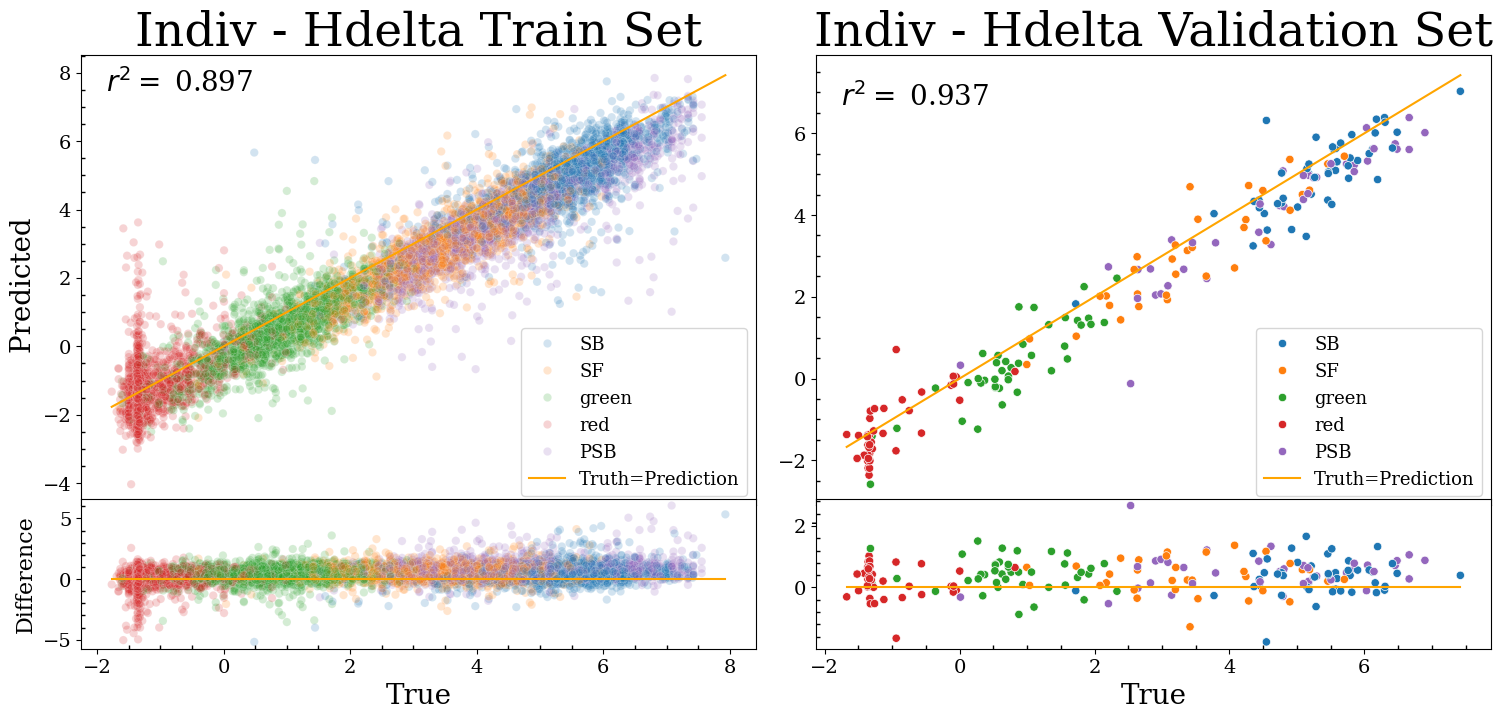

In [185]:
# plot for indiv models
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
#graphPredictionTruth(*trainGraphdata_1_fgal,*validGraphdata_1_fgal, 'Indiv - fgal',ax, True, le)
#graphPredictionTruth(*trainGraphdata_1_dn4,*validGraphdata_1_dn4, 'Indiv - dn4000',ax, True, le)
graphPredictionTruth(*trainGraphdata_1_hdel,*validGraphdata_1_hdel, 'Indiv - Hdelta',ax, True, le)

#### Concat Model- At start

In [136]:
# make predictions for graph
trainGraphdata_2_fgal,validGraphdata_2_fgal= dataFor_graphPredictionTruth(model_fgal_Version2, graphTrain_data_loader,
                                                                          graphValid_data_loader, 'f-gal')

# use predictions to make combine flux and predicted f-gal to the data needed for next model
graphTrain_dataset_2=graphDatasetmodifier(graphTrainDataset, trainGraphdata_2_fgal[0], None)
graphValid_dataset_2=graphDatasetmodifier(graphValidDataset, validGraphdata_2_fgal[0], None)

graphTrain_data_loader_2 = data.DataLoader(graphTrain_dataset_2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_2 = data.DataLoader(graphValid_dataset_2, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_2_dn4,validGraphdata_2_dn4= dataFor_graphPredictionTruth(model_dn4000_Version2, graphTrain_data_loader_2,
                                                                          graphValid_data_loader_2, 'dn4000')

# use predictions to make combine flux + predicted f-gal with predicted dn4000 to the data needed for next model
graphTrain_dataset_3=graphDatasetmodifier(graphTrain_dataset_2, None, trainGraphdata_2_dn4[0])
graphValid_dataset_3=graphDatasetmodifier(graphValid_dataset_2, None, validGraphdata_2_dn4[0])

graphTrain_data_loader_3 = data.DataLoader(graphTrain_dataset_3, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_3 = data.DataLoader(graphValid_dataset_3, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_2_hdel,validGraphdata_2_hdel= dataFor_graphPredictionTruth(model_hdelta_Version2, graphTrain_data_loader_3,
                                                                          graphValid_data_loader_3, 'hdelta')



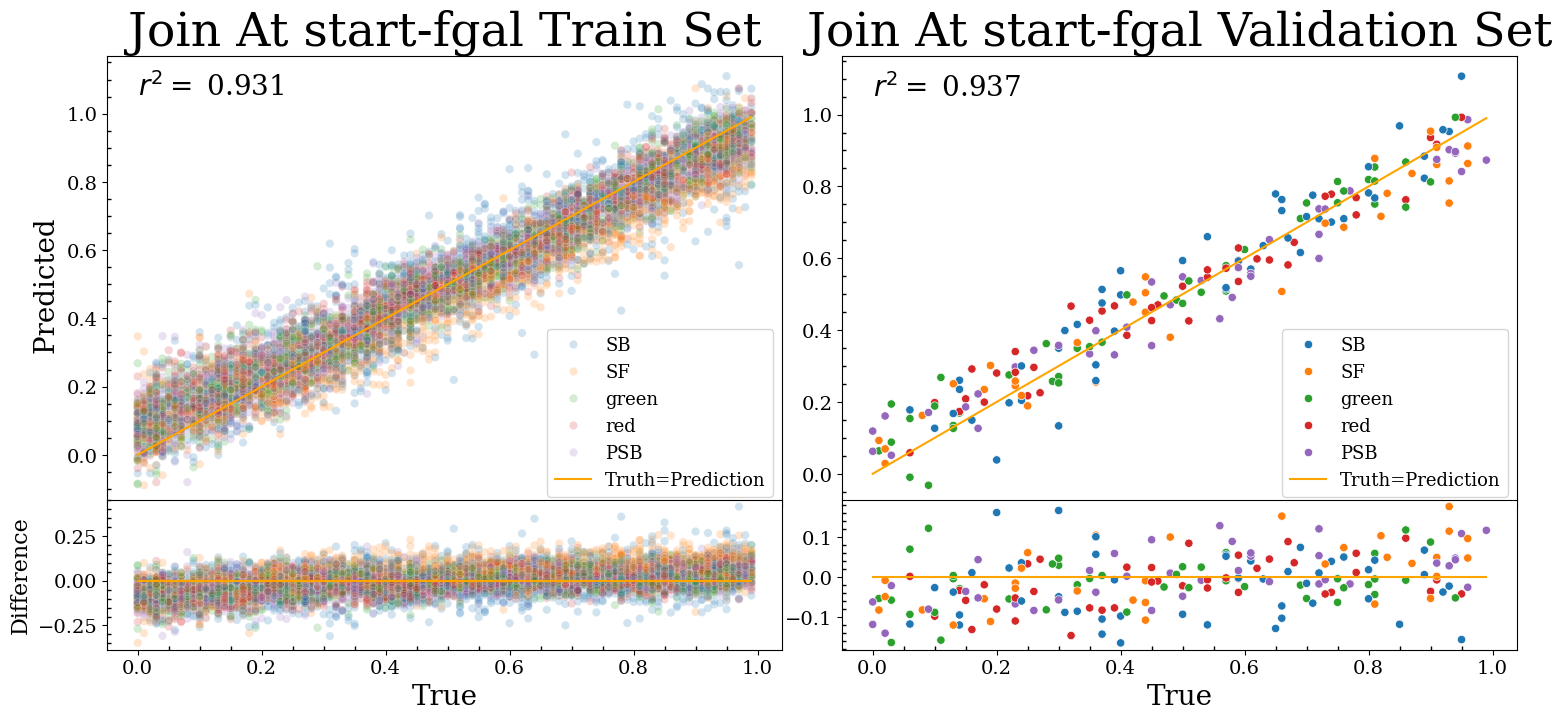

In [191]:
# plot for concat models
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
graphPredictionTruth(*trainGraphdata_2_fgal,*validGraphdata_2_fgal, 'Join At start-fgal',ax, True, le)
#graphPredictionTruth(*trainGraphdata_2_dn4,*validGraphdata_2_dn4, 'Join at start-dn4',ax, True, le)
#graphPredictionTruth(*trainGraphdata_2_hdel,*validGraphdata_2_hdel, 'Join at start-Hdel',ax, True, le)

#### Concat Model- At fully connected layer

The way the model takes in flux + previous predictions as a new channel but then squeezes it down to 1 value to add to the FC layer is very janky and requires a different dataFor_graphpreidctionTruth function.

In [231]:
#graph
def dataFor_graphPredictionTruth_FCSPECIFIC(model, train_data_loader, valid_data_loder, predictingWhat):
    # returns model predictions on training and validation data, specific to the connected at fc layer models
    model.eval()
    predict_train=np.array([])
    truth_train=np.array([])
    diff_train=np.array([])
    hue_train=np.array([])

    predict_val=np.array([])
    truth_val=np.array([])
    diff_val=np.array([])
    hue_val=np.array([])

    for flux, f_gal, dn4000, hdelta, gal_type_code in train_data_loader:
        with torch.no_grad():
            trial_batch_p=flux.to(device)
            trial_batch_hue=gal_type_code

            if predictingWhat == 'f-gal':
                trial_batch_t=f_gal.to(device)
            elif  predictingWhat == 'dn4000' :
                trial_batch_t=dn4000.to(device)
            elif predictingWhat == 'hdelta':
                trial_batch_t=hdelta.to(device)

            if trial_batch_p.shape[1] not in [1,2,3]:
                trial_batch_p=trial_batch_p.unsqueeze(1)

            batch_flux=trial_batch_p[:,0,:].to(device).unsqueeze(1)
            if flux.shape[1] == 2:
                previousPredictions= flux[:,1,:][:,0].unsqueeze(1).to(device)
            elif flux.shape[1] == 3:
                batch_fgal= flux[:,1,:][:,0].unsqueeze(1).to(device)
                batch_dn4000= flux[:,2,:][:,0].unsqueeze(1).to(device)
                previousPredictions=torch.concat((batch_fgal,batch_dn4000), dim=1)
            else:
                previousPredictions=None


            predict_train=np.append(predict_train, model(batch_flux, previousPredictions).cpu().squeeze().detach().numpy())
        truth_train=np.append(truth_train, trial_batch_t.cpu().detach().numpy())
        hue_train=np.append(hue_train, trial_batch_hue.cpu().detach().numpy())

    diff_train=np.append(diff_train,truth_train-predict_train)


    for flux, f_gal, dn4000, hdelta, gal_type_code in valid_data_loder:
        with torch.no_grad():
            trial_batch_p=flux.to(device)
            trial_batch_hue=gal_type_code

            if predictingWhat == 'f-gal':
                trial_batch_t=f_gal.to(device)
            elif  predictingWhat == 'dn4000' :
                trial_batch_t=dn4000.to(device)
            elif predictingWhat == 'hdelta':
                trial_batch_t=hdelta.to(device)

            if trial_batch_p.shape[1] not in [1,2,3]:
                trial_batch_p=trial_batch_p.unsqueeze(1)


            batch_flux=trial_batch_p[:,0,:].to(device).unsqueeze(1)
            if flux.shape[1] == 2:
                previousPredictions= flux[:,1,:][:,0].unsqueeze(1).to(device)
            elif flux.shape[1] == 3:
                batch_fgal= flux[:,1,:][:,0].unsqueeze(1).to(device)
                batch_dn4000= flux[:,2,:][:,0].unsqueeze(1).to(device)
                previousPredictions=torch.concat((batch_fgal,batch_dn4000), dim=1)
            else:
                previousPredictions=None

            predict_val=np.append(predict_val,model(batch_flux, previousPredictions).cpu().squeeze().detach().numpy())
        truth_val=np.append(truth_val,trial_batch_t.cpu().detach().numpy())
        hue_val=np.append(hue_val, trial_batch_hue.cpu().detach().numpy())

    diff_val=truth_val-predict_val


    return [predict_train,truth_train,diff_train, hue_train], [predict_val,truth_val,diff_val,hue_val]



In [232]:
# make predictions for graph
trainGraphdata_3_fgal,validGraphdata_3_fgal= dataFor_graphPredictionTruth(model_fgal_Version3, graphTrain_data_loader,
                                                                          graphValid_data_loader, 'f-gal')

# use predictions to make combine flux and predicted f-gal to the data needed for next model
graphTrain_dataset_M3_2=graphDatasetmodifier(graphTrainDataset, trainGraphdata_3_fgal[0], None)
graphValid_dataset_M3_2=graphDatasetmodifier(graphValidDataset, validGraphdata_3_fgal[0], None)

graphTrain_data_loader_M3_2 = data.DataLoader(graphTrain_dataset_M3_2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_M3_2 = data.DataLoader(graphValid_dataset_M3_2, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_3_dn4,validGraphdata_3_dn4= dataFor_graphPredictionTruth_FCSPECIFIC(model_dn4000_Version3, graphTrain_data_loader_M3_2,
                                                                          graphValid_data_loader_M3_2, 'dn4000')

# use predictions to make combine flux + predicted f-gal with predicted dn4000 to the data needed for next model
graphTrain_dataset_M3_3=graphDatasetmodifier(graphTrain_dataset_M3_2, None, trainGraphdata_3_dn4[0])
graphValid_dataset_M3_3=graphDatasetmodifier(graphValid_dataset_M3_2, None, validGraphdata_3_dn4[0])

graphTrain_data_loader_M3_3 = data.DataLoader(graphTrain_dataset_M3_3, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_M3_3 = data.DataLoader(graphValid_dataset_M3_3, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_3_hdel,validGraphdata_3_hdel= dataFor_graphPredictionTruth_FCSPECIFIC(model_hdelta_Version3, graphTrain_data_loader_M3_3,
                                                                          graphValid_data_loader_M3_3, 'hdelta')



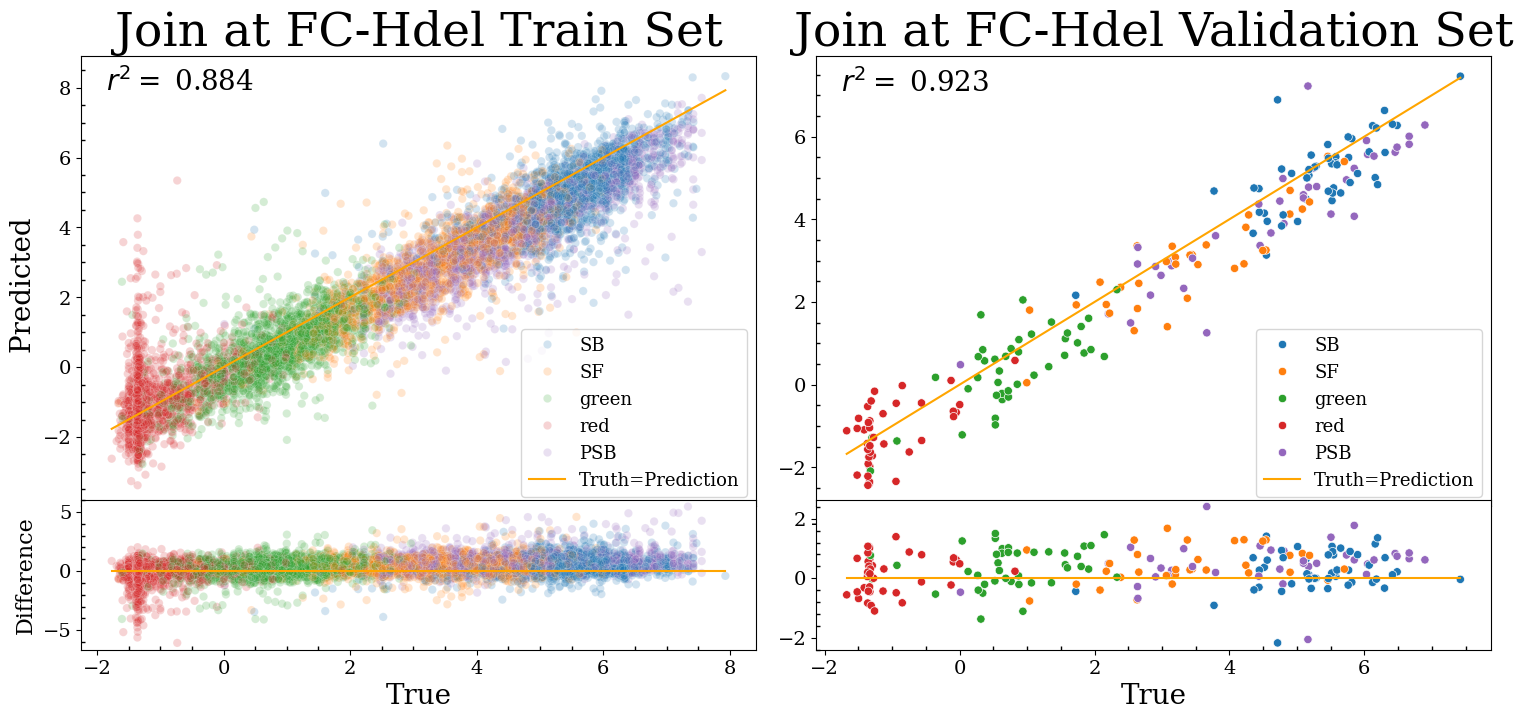

In [234]:
# plot for concat models
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
#graphPredictionTruth(*trainGraphdata_3_fgal,*validGraphdata_3_fgal, 'Join At FC-fgal',ax, True, le)
#graphPredictionTruth(*trainGraphdata_3_dn4,*validGraphdata_3_dn4, 'Join at FC-dn4',ax, True, le)
graphPredictionTruth(*trainGraphdata_3_hdel,*validGraphdata_3_hdel, 'Join at FC-Hdel',ax, True, le)

#### Simultaneous training

In [226]:
# make predictions for graph
trainGraphdata_4_fgal,validGraphdata_4_fgal= dataFor_graphPredictionTruth(model_fgal_simul, graphTrain_data_loader,
                                                                          graphValid_data_loader, 'f-gal')

# use predictions to make combine flux and predicted f-gal to the data needed for next model
graphTrain_dataset_M4_2=graphDatasetmodifier(graphTrainDataset, trainGraphdata_4_fgal[0], None)
graphValid_dataset_M4_2=graphDatasetmodifier(graphValidDataset, validGraphdata_4_fgal[0], None)

graphTrain_data_loader_M4_2 = data.DataLoader(graphTrain_dataset_M4_2, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_M4_2 = data.DataLoader(graphValid_dataset_M4_2, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_4_dn4,validGraphdata_4_dn4= dataFor_graphPredictionTruth(model_dn4_simul, graphTrain_data_loader_M4_2,
                                                                          graphValid_data_loader_M4_2, 'dn4000')

# use predictions to make combine flux + predicted f-gal with predicted dn4000 to the data needed for next model
graphTrain_dataset_M4_3=graphDatasetmodifier(graphTrain_dataset_M4_2, None, trainGraphdata_4_dn4[0])
graphValid_dataset_M4_3=graphDatasetmodifier(graphValid_dataset_M4_2, None, validGraphdata_4_dn4[0])

graphTrain_data_loader_M4_3 = data.DataLoader(graphTrain_dataset_M4_3, batch_size=TRAIN_BATCH_SIZE, num_workers=0, pin_memory=False ,shuffle=False)
graphValid_data_loader_M4_3 = data.DataLoader(graphValid_dataset_M4_3, batch_size=VALID_BATCH_SIZE, shuffle=False)

# make predictions again
trainGraphdata_4_hdel,validGraphdata_4_hdel= dataFor_graphPredictionTruth(model_hdel_simul, graphTrain_data_loader_M4_3,
                                                                          graphValid_data_loader_M4_3, 'hdelta')



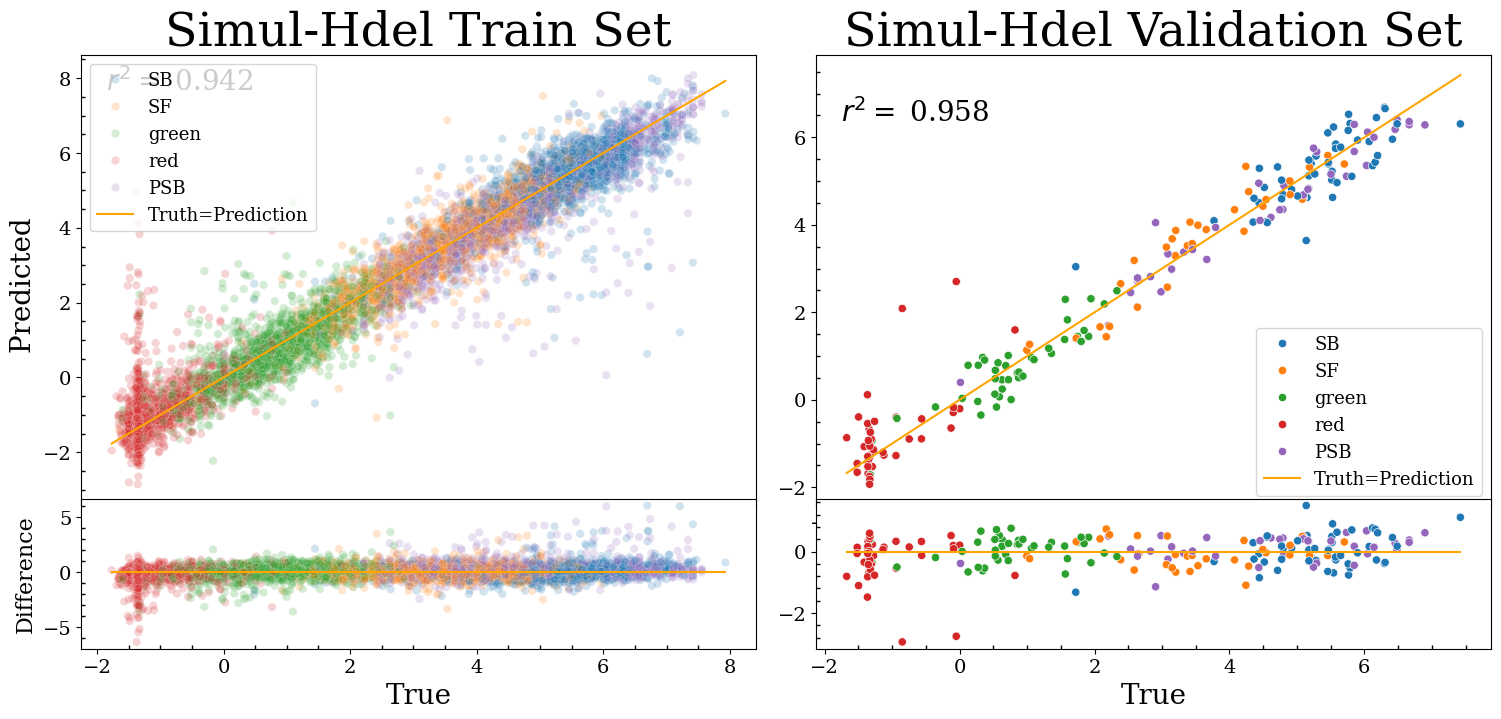

In [236]:
# plot for concat models
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
#graphPredictionTruth(*trainGraphdata_4_fgal,*validGraphdata_4_fgal, 'Simul-fgal',ax, True, le)
#graphPredictionTruth(*trainGraphdata_4_dn4,*validGraphdata_4_dn4, 'Simul-dn4',ax, True, le)
graphPredictionTruth(*trainGraphdata_4_hdel,*validGraphdata_4_hdel, 'Simul-Hdel',ax, True, le)

## Save loss data

In [ ]:
AllLossCurves=np.array([M1_fgal_trainLossCurve,M1_dn4_trainLossCurve,M1_hdelta_trainLossCurve,M1_fgal_validLossCurve,M1_dn4_validLossCurve,M1_hdelta_validLossCurve,
                        M2_fgal_trainLossCurve,M2_dn4_trainLossCurve,M2_hdelta_trainLossCurve,M2_fgal_validLossCurve,M2_dn4_validLossCurve,M2_hdelta_validLossCurve,
                        M2P2_fgal_trainLossCurve,M2P2_dn4_trainLossCurve,M2P2_hdelta_trainLossCurve,M2P2_fgal_validLossCurve,M2P2_dn4_validLossCurve,M2P2_hdelta_validLossCurve,
                        M3_fgal_trainLossCurve,M3_dn4_trainLossCurve,M3_hdelta_trainLossCurve,M3_fgal_validLossCurve,M3_dn4_validLossCurve,M3_hdelta_validLossCurve])


# Save the array as a CSV
np.savetxt('/content/drive/MyDrive/3 model data/AllLoseCurves.csv', AllLossCurves, delimiter=',')

In [ ]:
import numpy as np

# Read the CSV file into a NumPy array
array = np.loadtxt('/content/drive/MyDrive/3 model data/AllLoseCurves.csv', delimiter=',')

# Print the array
array

array([[0.06092871, 0.02201767, 0.01560373, ..., 0.00640992, 0.00651508,
        0.00645551],
       [0.1358877 , 0.04942167, 0.04522767, ..., 0.0226214 , 0.0227742 ,
        0.02269939],
       [4.66540688, 2.92327296, 2.56076544, ..., 0.40647455, 0.41352793,
        0.42804028],
       ...,
       [0.04954263, 0.03884825, 0.03555505, ..., 0.00773152, 0.00796556,
        0.00772105],
       [0.05281271, 0.04850658, 0.04036002, ..., 0.0166449 , 0.01631988,
        0.01630816],
       [5.38545084, 3.40373814, 2.37398911, ..., 1.55083001, 1.56477058,
        1.57696152]])

## Grad Cam

In [237]:
from captum.attr import (
    GradientShap,
    DeepLift,
    DeepLiftShap,
    IntegratedGradients,
    GuidedGradCam,
    LayerConductance,
    NeuronConductance,
    NoiseTunnel,
    LayerGradCam,
    LayerAttribution)

from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap

In [238]:
batch=next(iter(valid_data_loader))

In [239]:
genericwavelengthArray=firstDataset['wl'].iloc[[0]][0]

In [240]:
allModels={'model_fgal_indv':model_fgal_indv, 'model_dn4_indv':model_dn4_indv ,'model_hdelta_indv':model_hdelta_indv,
           'model_fgal_Version2':model_fgal_Version2,'model_dn4000_Version2':model_dn4000_Version2,'model_hdelta_Version2':model_hdelta_Version2,
           'model_fgal_Version3':model_fgal_Version3,'model_dn4000_Version3':model_dn4000_Version3,'model_hdelta_Version3':model_hdelta_Version3,
           'model_fgal_simul':model_fgal_simul,'model_dn4_simul':model_dn4_simul,'model_hdel_simul':model_hdel_simul}

In [270]:
dataindx=4
input=batch[0][dataindx].unsqueeze(0).unsqueeze(1).to(device)
frac=batch[1][dataindx].to(device)
label=batch[2][dataindx].to(device)
print(frac.item(), label.item())
ModelKey="model_fgal_indv" #@param ['model_fgal_indv', 'model_dn4_indv' ,'model_hdelta_indv','model_fgal_Version2','model_dn4000_Version2','model_hdelta_Version2','model_fgal_Version3','model_dn4000_Version3','model_hdelta_Version3', 'model_fgal_simul','model_dn4_simul','model_hdel_simul']
Model=allModels[ModelKey]
Model.eval()
Model.to(device)
pass

0.4399999976158142 4.0


In [272]:
grad

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

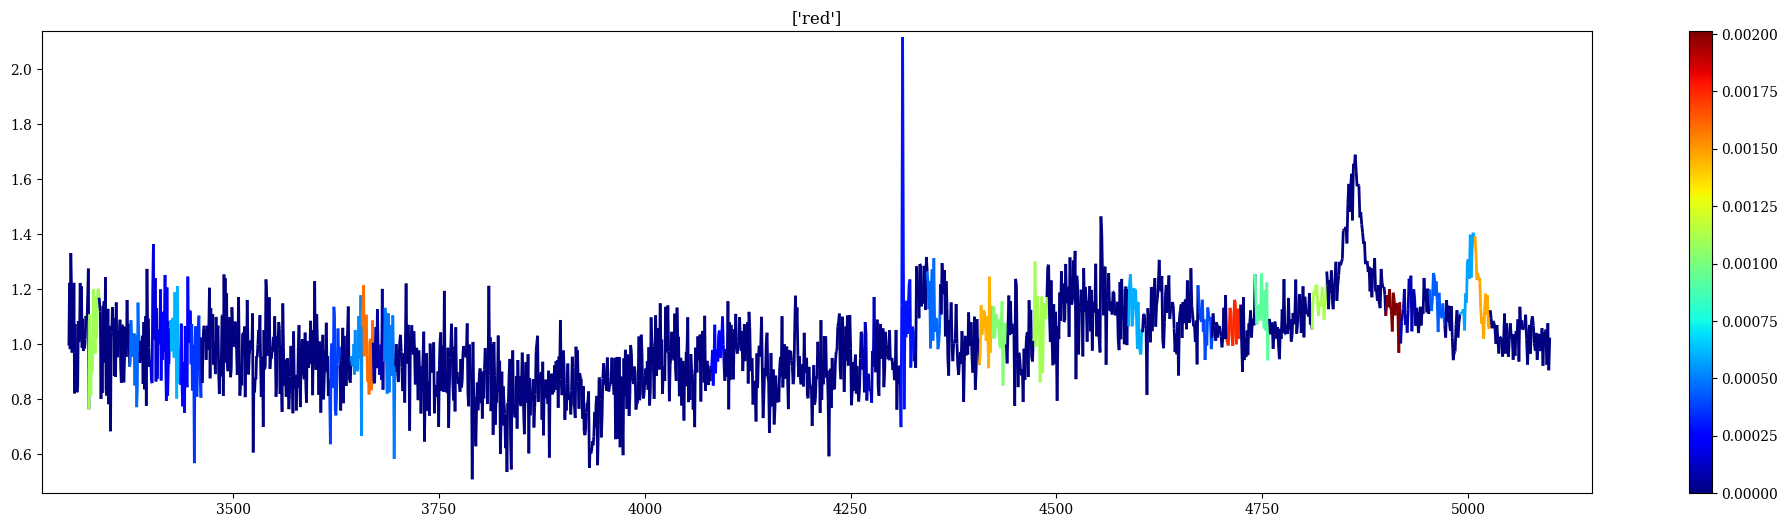

In [271]:
input.requires_grad = True
gradcam = LayerGradCam(Model, Model.middleLayersPart2[4].conv3.conv) # Compute gradcam for last conv
gradcam_out = gradcam.attribute(input, target=None, relu_attributions=True) # no target needed due to being a single output regressor
gradcam_out = LayerAttribution.interpolate(gradcam_out, (1890)) # Upsample to match the input dimension
grad=gradcam_out.cpu().detach().numpy().squeeze()


x=genericwavelengthArray
y=batch[0][dataindx]
z=grad


points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

fig, ax =plt.subplots(figsize=(25,6))
ax.set_title(le.inverse_transform([int(label.item())]))

ax.set_xlim(min(x)*0.99, max(x)*1.01)
ax.set_ylim(y.min()*0.9, y.max()*1.01)

norm = plt.Normalize(z.min(), z.max())
lc = LineCollection(segments, cmap='jet', norm=norm)
lc.set_array(z)
lc.set_linewidth(2)
line = ax.add_collection(lc)
fig.colorbar(line, ax=ax)

# poster

-1.5121581382752982
943 944
4101.0966 4102.041
0.8135601425820792 1.0204078177271403


<ipython-input-245-ea33c940f30f>:18: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(4100,4100)


(3895.0, 4305.0)

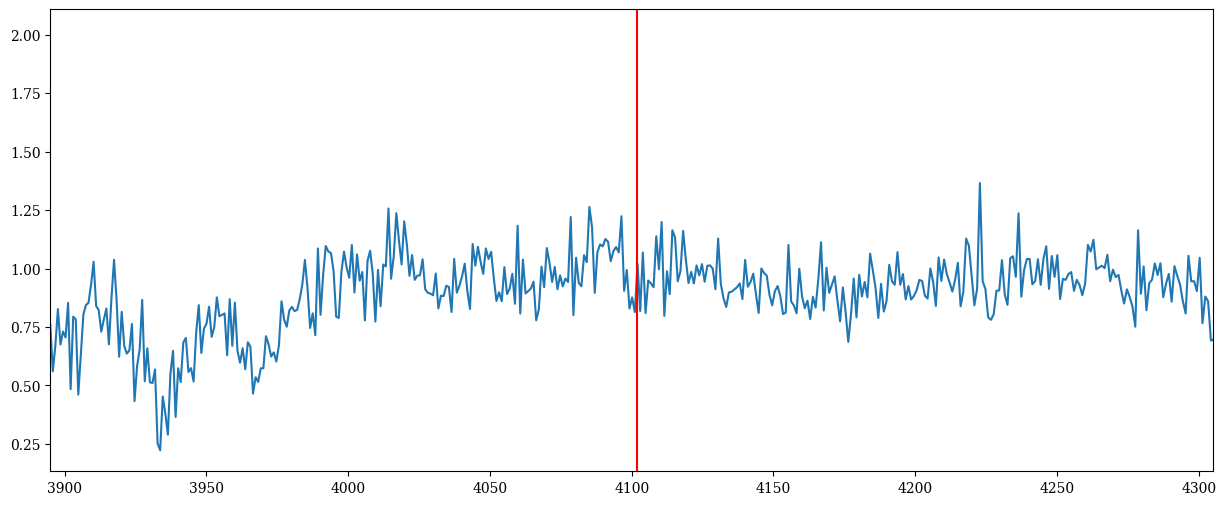

In [ ]:
file_path=filePaths[1]
fig, ax =plt.subplots(figsize=(15,6))
with open(file_path, "rb") as f:
    data = pickle.load(f)
    data['wl'] = data['wl'].flatten()

    ax.plot(data['wl'], data['flux'])
    print(data['hdelta'])

plt.axvline(x=4101.734, color='red')

a=np.where(data['wl'] <= 4101.734)[0][-1]
b=np.where(data['wl'] >= 4101.734)[0][0]
print(a,b)
print(data['wl'][a],data['wl'][b])
print(data['flux'][a],data['flux'][b])

ax.set_xlim(4100,4100)


#fig.savefig('poster fig1 -1', bbox_inches='tight', dpi=1000)